# Optimización del nesting 2D irregular mediante Algoritmos Genéticos

Este notebook implementa y analiza un Algoritmo Genético para optimizar el problema de nesting 2D irregular correspondiente a la instancia SHIRTS.

El objetivo consiste en ubicar las 99 piezas sobre una tela de ancho fijo, **minimizando la longitud total utilizada** y respetando las restricciones geométricas del problema.

La solución se divide en dos componentes:

- **Algoritmo Genético:** optimiza el orden de colocación y la orientación de las piezas.
- **Decoder geométrico:** determina las coordenadas de cada pieza a partir del cromosoma utilizando las relaciones IFP (*Inner-Fit Polygon*) y NFP (*No-Fit Polygon*).

Por lo tanto, las coordenadas `(x, y)` no forman parte del cromosoma: son determinadas de forma determinística por el decoder.

A lo largo del notebook se evalúan distintas configuraciones del GA, analizando su convergencia, diversidad poblacional y calidad de las soluciones obtenidas.

In [13]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import pandas as pd

from nesting.dataset import load_problem
from nesting.decoder import decode_solution
from nesting.geometry import validate_layout
from nesting.genetic_algorithm import (
    create_area_heuristic_genome,
    create_deap_individual,
    create_perturbed_genome,
    create_random_genome,
    create_toolbox,
    evaluate_individual,
    genome_key,
    mate_individuals,
    mutate_individual,
    run_genetic_algorithm,
    split_individual,
    validate_genome,
    create_mixed_population,
)
from nesting.visualization import plot_layout

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Carga del problema

Se utiliza la instancia SHIRTS del conjunto de problemas ESICUP.

El archivo XML contiene:

- la geometría del tablero;
- los distintos tipos de piezas y sus cantidades;
- las orientaciones permitidas;
- los polígonos IFP utilizados para respetar los límites del tablero;
- los polígonos NFP utilizados para evitar solapamientos.

La instancia contiene 99 piezas y admite orientaciones de `0°` y `180°`. El ancho de la tela permanece fijo, mientras que la longitud utilizada constituye la variable que se desea minimizar.

In [14]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

XML_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "shirts.xml"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "results"
    / "ga"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "ga"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

problem = load_problem(XML_PATH)

N_PIECES = len(problem.piece_instances)

board_min_x, board_min_y, board_max_x, board_max_y = (
    problem.board_geometry.bounds
)

BOARD_WIDTH = (
    board_max_y
    - board_min_y
)

TOTAL_PIECE_AREA = sum(
    problem.geometries[
        instance.polygon_id
    ].area
    for instance in problem.piece_instances
)

AREA_LOWER_BOUND = (
    TOTAL_PIECE_AREA
    / BOARD_WIDTH
)

print(f"Problema: {problem.name}")
print(f"Cantidad de piezas: {N_PIECES}")
print(f"Ancho de tela: {BOARD_WIDTH:.2f}")
print(f"Área total de piezas: {TOTAL_PIECE_AREA:.2f}")
print(
    "Cota inferior por área:",
    f"{AREA_LOWER_BOUND:.2f}",
)
print(
    "Longitud del cromosoma:",
    2 * N_PIECES,
)

Problema: Shirts
Cantidad de piezas: 99
Ancho de tela: 40.00
Área total de piezas: 2160.00
Cota inferior por área: 54.00
Longitud del cromosoma: 198


## 2. Representación del individuo

Cada individuo del algoritmo genético posee **198 genes**, divididos en dos bloques de 99 elementos:

$$
\text{individuo}
=
\left[
\text{orden de piezas}
\;\middle|\;
\text{orientaciones}
\right]
$$

### Orden de colocación

Los primeros 99 genes forman una **permutación de los `instance_id`**. Esta parte determina la secuencia en la que el decoder intenta colocar las piezas.

### Orientaciones

Los últimos 99 genes indican la orientación asignada a cada instancia. En la instancia SHIRTS las orientaciones posibles son `0°` y `180°`.

Las orientaciones se almacenan indexadas por `instance_id`, independientemente de la posición que tenga la pieza en el orden.

Esta codificación permite que el algoritmo genético explore distintas secuencias y orientaciones mientras el decoder se ocupa de determinar posiciones geométricamente factibles.

In [15]:
rng = random.Random(42)

random_genome = create_random_genome(
    problem=problem,
    rng=rng,
)

random_order, random_orientations = (
    split_individual(
        individual=random_genome,
        n_pieces=N_PIECES,
    )
)

is_valid, genome_errors = validate_genome(
    problem=problem,
    individual=random_genome,
)

print(
    "Longitud del individuo:",
    len(random_genome),
)

print(
    "Piezas en el orden:",
    len(random_order),
)

print(
    "Instancias únicas:",
    len(set(random_order)),
)

print(
    "Orientaciones:",
    len(random_orientations),
)

print(
    "Individuo válido:",
    is_valid,
)

Longitud del individuo: 198
Piezas en el orden: 99
Instancias únicas: 99
Orientaciones: 99
Individuo válido: True


## 3. Solución inicial heurística

Antes de ejecutar el algoritmo genético se construye una solución de referencia utilizando una heurística simple: ordenar las piezas de mayor a menor área.

La orientación inicial de cada pieza corresponde a la primera orientación permitida (`0°` para esta instancia).

Esta solución no pretende ser óptima. Su objetivo es proporcionar:

- una referencia para comparar las soluciones evolutivas;
- un individuo inicial de calidad razonable;
- una región prometedora del espacio de búsqueda a partir de la cual generar perturbaciones.

In [16]:
area_genome = create_area_heuristic_genome(
    problem
)

area_valid, area_errors = validate_genome(
    problem=problem,
    individual=area_genome,
)

area_order, area_orientations = (
    split_individual(
        individual=area_genome,
        n_pieces=N_PIECES,
    )
)

print(
    "Heurística válida:",
    area_valid,
)

print(
    "Primeras 10 instancias:",
    area_order[:10],
)

Heurística válida: True
Primeras 10 instancias: [16, 17, 18, 19, 20, 21, 22, 23, 8, 9]


## 4. Función objetivo y caché de evaluaciones

La aptitud de un individuo se obtiene decodificando completamente su cromosoma y calculando la **longitud de tela utilizada**:

$$
f(x) = L_{\mathrm{utilizada}}
$$

El problema se plantea como una **minimización**, por lo que una menor longitud representa una mejor solución.

La evaluación es computacionalmente costosa porque requiere construir un layout geométrico completo de 99 piezas. Por este motivo se utiliza una caché indexada por el cromosoma: si un individuo ya fue evaluado anteriormente, su fitness se recupera sin volver a ejecutar el decoder.

In [17]:
fitness_cache = {}

start_time = time.perf_counter()

area_fitness = evaluate_individual(
    individual=area_genome,
    problem=problem,
    cache=fitness_cache,
)[0]

first_evaluation_time = (
    time.perf_counter()
    - start_time
)

start_time = time.perf_counter()

area_fitness_cached = evaluate_individual(
    individual=area_genome,
    problem=problem,
    cache=fitness_cache,
)[0]

cached_evaluation_time = (
    time.perf_counter()
    - start_time
)

print(
    "Longitud heurística:",
    f"{area_fitness:.2f}",
)

print(
    "Primera evaluación:",
    f"{first_evaluation_time:.2f} s",
)

print(
    "Evaluación desde caché:",
    f"{cached_evaluation_time:.6f} s",
)

Longitud heurística: 76.94
Primera evaluación: 12.85 s
Evaluación desde caché: 0.000147 s


## 5. Operadores evolutivos

El cromosoma contiene dos tipos de información con restricciones diferentes, por lo que se utilizan operadores específicos para cada bloque.

### Crossover

- **Orden:** se utiliza *Ordered Crossover (OX)* para conservar una permutación válida de las 99 instancias.
- **Orientaciones:** se utiliza crossover uniforme, intercambiando las orientaciones entre los padres.

### Mutación

- **Orden:** se modifican posiciones del orden sin introducir instancias duplicadas.
- **Orientaciones:** una pieza puede cambiar a otra de sus orientaciones permitidas.

Antes de ejecutar los experimentos se comprueba que ambos operadores continúan produciendo cromosomas válidos.

In [18]:
# Semillas para reproducibilidad
rng = random.Random(42)
random.seed(42)

# --------------------------------------------------
# 1. Crear dos padres aleatorios
# --------------------------------------------------

parent_1 = create_random_genome(
    problem=problem,
    rng=rng,
)

parent_2 = create_random_genome(
    problem=problem,
    rng=rng,
)

parent_1_order, parent_1_orientations = (
    split_individual(
        parent_1,
        N_PIECES,
    )
)

parent_2_order, parent_2_orientations = (
    split_individual(
        parent_2,
        N_PIECES,
    )
)

print("PADRES")
print("-" * 60)

print(
    "Padre 1 - primeras 10 piezas:",
    parent_1_order[:10],
)

print(
    "Padre 1 - primeras 10 orientaciones:",
    parent_1_orientations[:10],
)

print()

print(
    "Padre 2 - primeras 10 piezas:",
    parent_2_order[:10],
)

print(
    "Padre 2 - primeras 10 orientaciones:",
    parent_2_orientations[:10],
)

PADRES
------------------------------------------------------------
Padre 1 - primeras 10 piezas: [72, 60, 90, 9, 33, 26, 1, 74, 15, 62]
Padre 1 - primeras 10 orientaciones: [0, 180, 0, 180, 180, 180, 0, 180, 0, 0]

Padre 2 - primeras 10 piezas: [76, 4, 92, 15, 65, 58, 36, 22, 8, 67]
Padre 2 - primeras 10 orientaciones: [0, 180, 180, 180, 0, 0, 180, 0, 0, 0]


In [19]:
# --------------------------------------------------
# 2. Aplicar crossover
# --------------------------------------------------
### el hijo mezcla información de ambos padres, 
# pero sigue conteniendo exactamente las 99 instancias una sola vez.

child_1 = parent_1.copy()
child_2 = parent_2.copy()

mate_individuals(
    individual_1=child_1,
    individual_2=child_2,
    n_pieces=N_PIECES,
)

child_1_order, child_1_orientations = (
    split_individual(
        child_1,
        N_PIECES,
    )
)

child_2_order, child_2_orientations = (
    split_individual(
        child_2,
        N_PIECES,
    )
)

print("CROSSOVER")
print("-" * 60)

print(
    "Padre 1:",
    parent_1_order[:15],
)

print(
    "Hijo 1 :",
    child_1_order[:15],
)

print()

print(
    "Padre 2:",
    parent_2_order[:15],
)

print(
    "Hijo 2 :",
    child_2_order[:15],
)

print()

print(
    "Hijo 1 válido:",
    validate_genome(
        problem,
        child_1,
    )[0],
)

print(
    "Hijo 2 válido:",
    validate_genome(
        problem,
        child_2,
    )[0],
)

CROSSOVER
------------------------------------------------------------
Padre 1: [72, 60, 90, 9, 33, 26, 1, 74, 15, 62, 79, 10, 52, 89, 51]
Hijo 1 : [58, 76, 7, 55, 67, 22, 59, 6, 98, 43, 92, 53, 83, 77, 46]

Padre 2: [76, 4, 92, 15, 65, 58, 36, 22, 8, 67, 77, 39, 53, 14, 46]
Hijo 2 : [79, 10, 3, 87, 26, 11, 1, 90, 89, 9, 81, 35, 17, 31, 51]

Hijo 1 válido: True
Hijo 2 válido: True


In [20]:
# --------------------------------------------------
# 3. Aplicar mutación
# --------------------------------------------------

mutated_child = child_1.copy()

mutate_individual(
    individual=mutated_child,
    problem=problem,
    order_indpb=0.05,
    orientation_indpb=0.05,
)

mutated_order, mutated_orientations = (
    split_individual(
        mutated_child,
        N_PIECES,
    )
)

changed_order_positions = sum(
    original != mutated
    for original, mutated
    in zip(
        child_1_order,
        mutated_order,
    )
)

changed_orientations = sum(
    original != mutated
    for original, mutated
    in zip(
        child_1_orientations,
        mutated_orientations,
    )
)

print("MUTACIÓN")
print("-" * 60)

print(
    "Antes - primeras 15 piezas:",
    child_1_order[:15],
)

print(
    "Después - primeras 15 piezas:",
    mutated_order[:15],
)

print()

print(
    "Posiciones del orden modificadas:",
    changed_order_positions,
)

print(
    "Orientaciones modificadas:",
    changed_orientations,
)

print(
    "Individuo mutado válido:",
    validate_genome(
        problem,
        mutated_child,
    )[0],
)

MUTACIÓN
------------------------------------------------------------
Antes - primeras 15 piezas: [58, 76, 7, 55, 67, 22, 59, 6, 98, 43, 92, 53, 83, 77, 46]
Después - primeras 15 piezas: [97, 76, 7, 55, 67, 22, 59, 6, 58, 43, 92, 53, 83, 77, 46]

Posiciones del orden modificadas: 7
Orientaciones modificadas: 4
Individuo mutado válido: True


### Verificación de los operadores

Las pruebas anteriores permiten comprobar que los operadores modifican efectivamente los cromosomas sin violar su representación.

El crossover combina información de dos individuos conservando una permutación válida en el orden de colocación, mientras que la mutación introduce cambios tanto en el orden como en las orientaciones.

En todos los casos, `validate_genome()` verifica que:

- las 99 instancias aparezcan exactamente una vez en el orden;
- no existan piezas duplicadas;
- cada orientación pertenezca al conjunto permitido para la pieza.

Estas comprobaciones son importantes porque permiten que el algoritmo genético explore nuevas soluciones sin generar cromosomas incompatibles con el decoder.

## 6. Baselines de referencia

Antes de ejecutar el algoritmo genético se calculan dos soluciones de referencia.

### Baseline original

Se utiliza el orden natural de las 99 instancias (`0, 1, ..., 98`) y orientación `0°` para todas las piezas. Esta solución permite establecer una referencia simple, sin ningún criterio de optimización sobre el orden.

### Heurística por área

Como segunda referencia se utiliza la solución construida anteriormente, donde las piezas se ordenan de mayor a menor área.

Estas soluciones permiten cuantificar posteriormente la mejora obtenida mediante el algoritmo genético.

In [21]:
# --------------------------------------------------
# Baseline original
# --------------------------------------------------

baseline_order = list(range(N_PIECES))

baseline_orientations = [
    0
    for _ in range(N_PIECES)
]

start_time = time.perf_counter()

baseline_result = decode_solution(
    problem=problem,
    order=baseline_order,
    orientations=baseline_orientations,
)

baseline_time = (
    time.perf_counter()
    - start_time
)

baseline_length = (
    baseline_result.used_length
)

# --------------------------------------------------
# Heurística por área
# --------------------------------------------------

area_length = area_fitness

# Mejora relativa de la heurística respecto al baseline
area_improvement = (
    (baseline_length - area_length)
    / baseline_length
    * 100
)

# --------------------------------------------------
# Resultados
# --------------------------------------------------

print(
    "Baseline original:",
    f"{baseline_length:.2f}",
)

print(
    "Heurística por área:",
    f"{area_length:.2f}",
)

print(
    "Mejora de la heurística:",
    f"{area_improvement:.2f}%",
)

print(
    "Tiempo baseline:",
    f"{baseline_time:.2f} s",
)

Baseline original: 79.50
Heurística por área: 76.94
Mejora de la heurística: 3.21%
Tiempo baseline: 12.44 s


In [22]:
baseline_utilization = (
    TOTAL_PIECE_AREA
    / (
        BOARD_WIDTH
        * baseline_length
    )
    * 100
)

area_utilization = (
    TOTAL_PIECE_AREA
    / (
        BOARD_WIDTH
        * area_length
    )
    * 100
)

print(
    "Aprovechamiento baseline:",
    f"{baseline_utilization:.2f}%",
)

print(
    "Aprovechamiento heurística:",
    f"{area_utilization:.2f}%",
)

Aprovechamiento baseline: 67.92%
Aprovechamiento heurística: 70.18%


## 7. Construcción de una solución semilla

La heurística por área proporciona una solución considerablemente mejor que el orden original, pero no necesariamente constituye un óptimo local.

Para obtener un punto de partida más competitivo para el algoritmo genético se generan pequeñas perturbaciones de esta solución. Cada perturbación introduce:

- intercambios entre algunas posiciones del orden de colocación;
- cambios ocasionales en las orientaciones.

De esta forma se explora una vecindad próxima a la heurística sin generar una población completamente aleatoria.

La mejor solución obtenida en esta etapa se utilizará como **seed** de los experimentos posteriores.

In [23]:
rng = random.Random(42)

perturbed_genomes = [
    create_perturbed_genome(
        problem=problem,
        base_genome=area_genome,
        n_order_swaps=3,
        orientation_mutation_prob=0.03,
        rng=rng,
    )
    for _ in range(3)
]

for index, genome in enumerate(
    perturbed_genomes
):
    valid, errors = validate_genome(
        problem=problem,
        individual=genome,
    )

    print(
        f"Perturbado {index}: "
        f"válido={valid}"
    )

Perturbado 0: válido=True
Perturbado 1: válido=True
Perturbado 2: válido=True


In [24]:
base_order, base_orientations = (
    split_individual(
        area_genome,
        N_PIECES,
    )
)

for index, genome in enumerate(
    perturbed_genomes
):

    order, orientations = split_individual(
        genome,
        N_PIECES,
    )

    changed_order_positions = sum(
        original != modified
        for original, modified
        in zip(
            base_order,
            order,
        )
    )

    changed_orientations = sum(
        original != modified
        for original, modified
        in zip(
            base_orientations,
            orientations,
        )
    )

    print(
        f"Perturbado {index}: "
        f"{changed_order_positions} posiciones "
        f"del orden modificadas | "
        f"{changed_orientations} orientaciones "
        f"modificadas"
    )

Perturbado 0: 6 posiciones del orden modificadas | 1 orientaciones modificadas
Perturbado 1: 6 posiciones del orden modificadas | 3 orientaciones modificadas
Perturbado 2: 6 posiciones del orden modificadas | 1 orientaciones modificadas


In [25]:
seed_cache = {}

perturbed_results = []

for index, genome in enumerate(
    perturbed_genomes
):

    start_time = time.perf_counter()

    fitness = evaluate_individual(
        individual=genome,
        problem=problem,
        cache=seed_cache,
    )[0]

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    perturbed_results.append(
        fitness
    )

    print(
        f"Perturbado {index}: "
        f"L = {fitness:.2f} | "
        f"tiempo = {elapsed_time:.2f} s"
    )

Perturbado 0: L = 81.21 | tiempo = 12.01 s
Perturbado 1: L = 77.50 | tiempo = 15.25 s
Perturbado 2: L = 74.78 | tiempo = 11.41 s


In [26]:
seed_cache = {}

perturbed_results = []

for index, genome in enumerate(
    perturbed_genomes
):

    start_time = time.perf_counter()

    fitness = evaluate_individual(
        individual=genome,
        problem=problem,
        cache=seed_cache,
    )[0]

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    perturbed_results.append(
        fitness
    )

    print(
        f"Perturbado {index}: "
        f"L = {fitness:.2f} | "
        f"tiempo = {elapsed_time:.2f} s"
    )

Perturbado 0: L = 81.21 | tiempo = 14.94 s
Perturbado 1: L = 77.50 | tiempo = 9.80 s
Perturbado 2: L = 74.78 | tiempo = 8.01 s


In [27]:
# --------------------------------------------------
# Selección de la mejor perturbación como seed
# --------------------------------------------------

best_perturbed_index = min(
    range(len(perturbed_results)),
    key=lambda index: perturbed_results[index],
)

best_seed_genome = (
    perturbed_genomes[
        best_perturbed_index
    ].copy()
)

best_seed_fitness = (
    perturbed_results[
        best_perturbed_index
    ]
)

seed_improvement = (
    (area_length - best_seed_fitness)
    / area_length
    * 100
)

print(
    "Mejor perturbación:",
    best_perturbed_index,
)

print(
    "Longitud del seed:",
    f"{best_seed_fitness:.2f}",
)

print(
    "Mejora respecto de la heurística:",
    f"{seed_improvement:.2f}%",
)

print(
    "Seed válido:",
    validate_genome(
        problem,
        best_seed_genome,
    )[0],
)

Mejor perturbación: 2
Longitud del seed: 74.78
Mejora respecto de la heurística: 2.82%
Seed válido: True


### Resultado de la búsqueda local inicial

Las pequeñas perturbaciones muestran que el ordenamiento por área no constituye una solución localmente óptima.

La mejor perturbación obtenida reduce nuevamente la longitud utilizada respecto de la heurística inicial. Por este motivo se adopta esta solución como semilla para inicializar los experimentos con el algoritmo genético.

Este enfoque permite comenzar la evolución desde una región prometedora del espacio de búsqueda, manteniendo posteriormente diversidad mediante perturbaciones, crossover y mutación.

## 8. Funciones auxiliares para los experimentos

Para facilitar la comparación entre configuraciones, cada experimento se ejecutará siguiendo la misma estructura y sus resultados se almacenarán automáticamente.

Para cada corrida se guardan:

- historial por generación;
- parámetros utilizados;
- mejor cromosoma encontrado;
- resumen de métricas;
- curva de convergencia;
- layout correspondiente a la mejor solución.

El historial registra tanto la calidad de las soluciones como la diversidad genética de la población. Esto permite identificar fenómenos como convergencia prematura y analizar el equilibrio entre exploración y explotación.

In [28]:
def plot_experiment_history(
    history,
    title,
):
    """
    Grafica la evolución del mejor fitness y del
    fitness promedio de la población.
    """

    history_df = pd.DataFrame(history)

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.plot(
        history_df["generation"],
        history_df["best"],
        marker="o",
        label="Mejor individuo",
    )

    ax.plot(
        history_df["generation"],
        history_df["mean"],
        marker="o",
        label="Promedio de la población",
    )

    ax.set_xlabel("Generación")
    ax.set_ylabel("Longitud utilizada")
    ax.set_title(title)

    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    return fig, ax

In [29]:
def save_experiment_results(
    experiment_name,
    history,
    best_individual,
    parameters,
):
    """
    Guarda los resultados principales de un experimento.
    """

    experiment_results_dir = (
        RESULTS_DIR
        / experiment_name
    )

    experiment_figures_dir = (
        FIGURES_DIR
        / experiment_name
    )

    experiment_results_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    experiment_figures_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # --------------------------------------------------
    # Historial
    # --------------------------------------------------

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        experiment_results_dir
        / "history.csv",
        index=False,
    )

    # --------------------------------------------------
    # Mejor individuo
    # --------------------------------------------------

    best_genome = [
        int(gene)
        for gene in best_individual
    ]

    with open(
        experiment_results_dir
        / "best_genome.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            best_genome,
            file,
            indent=2,
        )

    # --------------------------------------------------
    # Parámetros
    # --------------------------------------------------

    with open(
        experiment_results_dir
        / "parameters.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            parameters,
            file,
            indent=2,
        )

    # --------------------------------------------------
    # Mejor layout
    # --------------------------------------------------

    best_order, best_orientations = (
        split_individual(
            best_genome,
            N_PIECES,
        )
    )

    best_result = decode_solution(
        problem=problem,
        order=best_order,
        orientations=best_orientations,
    )

    layout_valid, layout_errors = (
        validate_layout(
            board_geometry=(
                problem.board_geometry
            ),
            geometries=[
                placement.geometry
                for placement
                in best_result.placements
            ],
        )
    )

    utilization = (
        TOTAL_PIECE_AREA
        / (
            BOARD_WIDTH
            * best_result.used_length
        )
        * 100
    )

    # --------------------------------------------------
    # Resumen
    # --------------------------------------------------

    summary = {
        "best_length": float(
            best_result.used_length
        ),
        "utilization_percent": float(
            utilization
        ),
        "layout_valid": bool(
            layout_valid
        ),
        "layout_errors": len(
            layout_errors
        ),
        "best_generation": int(
            history_df.loc[
                history_df["best"].idxmin(),
                "generation",
            ]
        ),
        "final_unique_genomes": int(
            history_df.iloc[-1][
                "unique_genomes"
            ]
        ),
        "total_new_evaluations": int(
            history_df[
                "new_evaluations"
            ].sum()
        ),
        "total_time_s": float(
            history_df[
                "elapsed_time"
            ].sum()
        ),
    }

    with open(
        experiment_results_dir
        / "summary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            summary,
            file,
            indent=2,
        )

    # --------------------------------------------------
    # Curva de convergencia
    # --------------------------------------------------

    fig, ax = plot_experiment_history(
        history=history,
        title=(
            f"Convergencia - "
            f"{experiment_name}"
        ),
    )

    fig.savefig(
        experiment_figures_dir
        / "convergence.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.close(fig)

    # --------------------------------------------------
    # Layout
    # --------------------------------------------------

    fig, ax = plot_layout(
        result=best_result,
        board_width=BOARD_WIDTH,
        title=(
            f"{experiment_name} - "
            f"L = "
            f"{best_result.used_length:.2f}"
        ),
        show_reference_points=False,
        show_instance_ids=False,
    )

    fig.savefig(
        experiment_figures_dir
        / "best_layout.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.close(fig)

    return summary

## 9. Experimento 1 — Configuración inicial

El primer experimento utiliza una población pequeña construida alrededor de la mejor solución semilla obtenida previamente.

### Objetivo

Evaluar una configuración inicial del algoritmo genético y observar su comportamiento en términos de:

- mejora del fitness;
- velocidad de convergencia;
- diversidad genética de la población.

### Configuración

Se utiliza:

- población de 6 individuos;
- 1 solución semilla;
- 5 perturbaciones de la semilla;
- selección por torneo de tamaño 2;
- crossover con probabilidad 0.8;
- mutación con probabilidad 0.4;
- probabilidad interna de mutación de orden de 0.02;
- probabilidad interna de mutación de orientación de 0.02;
- elitismo de 1 individuo;
- 3 generaciones.

Esta primera configuración es deliberadamente pequeña debido al elevado costo computacional del decoder geométrico.

In [30]:
experiment_1_params = {
    "seed": 42,
    "population_size": 6,
    "n_generations": 3,
    "tournament_size": 2,
    "crossover_probability": 0.8,
    "mutation_probability": 0.4,
    "order_indpb": 0.02,
    "orientation_indpb": 0.02,
    "elite_size": 1,
    "n_perturbed": 5,
    "n_order_swaps": 3,
    "initial_orientation_mutation_prob": 0.03,
}

experiment_1_params

{'seed': 42,
 'population_size': 6,
 'n_generations': 3,
 'tournament_size': 2,
 'crossover_probability': 0.8,
 'mutation_probability': 0.4,
 'order_indpb': 0.02,
 'orientation_indpb': 0.02,
 'elite_size': 1,
 'n_perturbed': 5,
 'n_order_swaps': 3,
 'initial_orientation_mutation_prob': 0.03}

In [31]:
random.seed(
    experiment_1_params["seed"]
)

experiment_1_cache = {}

experiment_1_toolbox = create_toolbox(
    problem=problem,
    cache=experiment_1_cache,
    tournament_size=(
        experiment_1_params[
            "tournament_size"
        ]
    ),
    order_indpb=(
        experiment_1_params[
            "order_indpb"
        ]
    ),
    orientation_indpb=(
        experiment_1_params[
            "orientation_indpb"
        ]
    ),
)

experiment_1_population = (
    create_mixed_population(
        problem=problem,
        population_size=(
            experiment_1_params[
                "population_size"
            ]
        ),
        seed_genome=best_seed_genome,
        n_perturbed=(
            experiment_1_params[
                "n_perturbed"
            ]
        ),
        n_order_swaps=(
            experiment_1_params[
                "n_order_swaps"
            ]
        ),
        orientation_mutation_prob=(
            experiment_1_params[
                "initial_orientation_mutation_prob"
            ]
        ),
        rng=random.Random(
            experiment_1_params[
                "seed"
            ]
        ),
    )
)

print(
    "Tamaño de población:",
    len(experiment_1_population),
)

print(
    "Genomas únicos:",
    len({
        genome_key(individual)
        for individual
        in experiment_1_population
    }),
)

Tamaño de población: 6
Genomas únicos: 6


In [32]:
experiment_1_population_final, \
experiment_1_best, \
experiment_1_history = (
    run_genetic_algorithm(
        population=(
            experiment_1_population
        ),
        toolbox=(
            experiment_1_toolbox
        ),
        cache=(
            experiment_1_cache
        ),
        n_generations=(
            experiment_1_params[
                "n_generations"
            ]
        ),
        crossover_probability=(
            experiment_1_params[
                "crossover_probability"
            ]
        ),
        mutation_probability=(
            experiment_1_params[
                "mutation_probability"
            ]
        ),
        elite_size=(
            experiment_1_params[
                "elite_size"
            ]
        ),
    )
)

Generación 01 | best=74.78 | mean=78.97 | diversidad=5 | evals nuevas=3 | tiempo=23.54 s
Generación 02 | best=74.78 | mean=77.28 | diversidad=3 | evals nuevas=2 | tiempo=15.24 s
Generación 03 | best=74.78 | mean=74.78 | diversidad=1 | evals nuevas=0 | tiempo=0.00 s


In [33]:
experiment_1_history_df = pd.DataFrame(
    experiment_1_history
)

experiment_1_history_df

,generation,best,mean,worst,new_evaluations,unique_genomes,elapsed_time
0,0,74.777778,78.222222,79.777778,6,6,54.227488
1,1,74.777778,78.970899,87.000000,3,5,23.544443
2,2,74.777778,77.277778,84.777778,2,3,15.239946
3,3,74.777778,74.777778,74.777778,0,1,0.000883


In [34]:
experiment_1_unique_final = len({
    genome_key(individual)
    for individual
    in experiment_1_population_final
})

print(
    "Mejor longitud:",
    f"{experiment_1_best.fitness.values[0]:.2f}",
)

print(
    "Genomas únicos finales:",
    experiment_1_unique_final,
)

Mejor longitud: 74.78
Genomas únicos finales: 1


In [35]:
experiment_1_unique_final = len({
    genome_key(individual)
    for individual
    in experiment_1_population_final
})

print(
    "Mejor longitud:",
    f"{experiment_1_best.fitness.values[0]:.2f}",
)

print(
    "Genomas únicos finales:",
    experiment_1_unique_final,
)

Mejor longitud: 74.78
Genomas únicos finales: 1


In [36]:
experiment_1_summary = (
    save_experiment_results(
        experiment_name="experiment_1",
        history=experiment_1_history,
        best_individual=(
            experiment_1_best
        ),
        parameters=(
            experiment_1_params
        ),
    )
)

experiment_1_summary

{'best_length': 74.77777778000001,
 'utilization_percent': 72.21396730840374,
 'layout_valid': True,
 'layout_errors': 0,
 'best_generation': 0,
 'final_unique_genomes': 1,
 'total_new_evaluations': 11,
 'total_time_s': 93.0127594000005}

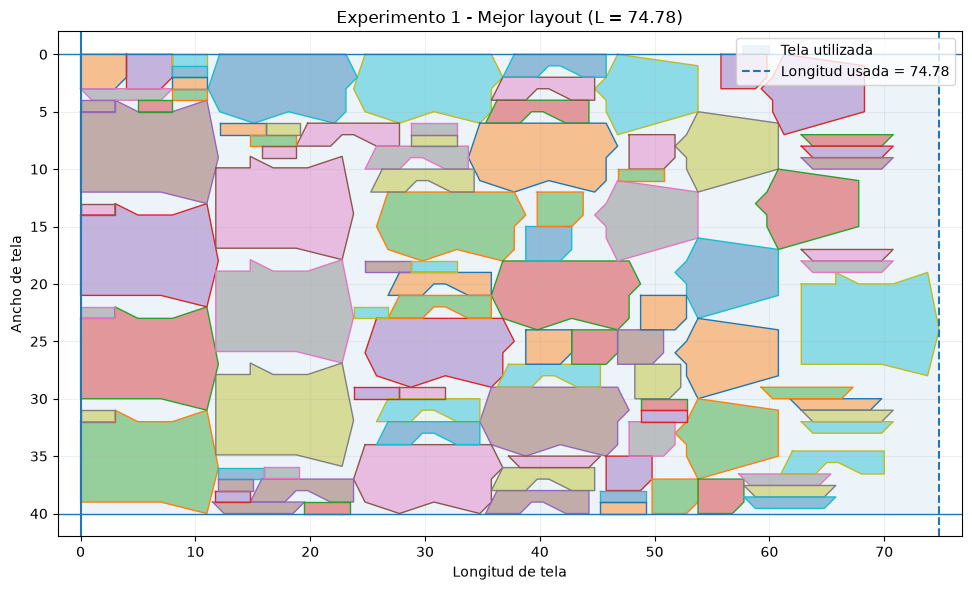

In [37]:
experiment_1_best_order, experiment_1_best_orientations = (
    split_individual(
        experiment_1_best,
        N_PIECES,
    )
)

experiment_1_best_result = decode_solution(
    problem=problem,
    order=experiment_1_best_order,
    orientations=experiment_1_best_orientations,
)

plot_layout(
    result=experiment_1_best_result,
    board_width=BOARD_WIDTH,
    title=(
        "Experimento 1 - Mejor layout "
        f"(L = {experiment_1_best_result.used_length:.2f})"
    ),
    show_reference_points=False,
    show_instance_ids=False,
)

plt.show()

### Análisis del Experimento 1

El experimento conserva la mejor solución inicial, pero no logra mejorar su longitud.

Además, la diversidad genética disminuye rápidamente hasta alcanzar un único genotipo en la población final. Esto indica un fenómeno de **convergencia prematura**: la presión de selección hace que la población se concentre alrededor del mejor individuo antes de explorar suficientemente otras regiones del espacio de búsqueda.

A partir de este resultado se decide modificar la estrategia de inicialización y aumentar la capacidad exploratoria del algoritmo en el siguiente experimento.

## 10. Experimento 2 — Aumento de diversidad

En el Experimento 1 se observó una rápida pérdida de diversidad genética: la población terminó formada por copias del mismo individuo y no se encontraron mejoras respecto de la solución semilla.

Para reducir este efecto se modifica la estrategia de búsqueda.

### Cambios introducidos

1. Se aumenta el tamaño de población de 6 a 8 individuos.
2. La población inicial se construye mediante perturbaciones de distinta intensidad alrededor de la solución semilla.
3. Se incrementa la probabilidad de mutación global.
4. Se incrementan las probabilidades internas de mutación del orden y de las orientaciones.

El objetivo de esta configuración es aumentar la **exploración del espacio de búsqueda** y retrasar la convergencia de la población hacia un único genotipo.

### Configuración

- población: 8 individuos;
- selección por torneo de tamaño 2;
- crossover: 0.8;
- mutación global: 0.7;
- mutación interna del orden: 0.04;
- mutación interna de orientación: 0.04;
- elitismo: 1 individuo;
- generaciones: 5.

In [38]:
experiment_2_params = {
    "seed": 42,
    "population_size": 8,
    "n_generations": 5,
    "tournament_size": 2,
    "crossover_probability": 0.8,
    "mutation_probability": 0.7,
    "order_indpb": 0.04,
    "orientation_indpb": 0.04,
    "elite_size": 1,
}

experiment_2_params

{'seed': 42,
 'population_size': 8,
 'n_generations': 5,
 'tournament_size': 2,
 'crossover_probability': 0.8,
 'mutation_probability': 0.7,
 'order_indpb': 0.04,
 'orientation_indpb': 0.04,
 'elite_size': 1}

### Población inicial diversificada

A diferencia del primer experimento, no se generan todos los vecinos con la misma intensidad.

La población se compone de:

- 1 copia de la solución semilla;
- 2 perturbaciones suaves;
- 3 perturbaciones intermedias;
- 2 perturbaciones fuertes.

Esto permite explorar regiones a distintas distancias de la mejor solución conocida sin recurrir a individuos completamente aleatorios, que en pruebas preliminares produjeron layouts considerablemente peores.

In [39]:
experiment_2_rng = random.Random(
    experiment_2_params["seed"]
)

experiment_2_genomes = [
    best_seed_genome.copy()
]

# --------------------------------------------------
# Perturbaciones suaves
# --------------------------------------------------

for _ in range(2):

    experiment_2_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=best_seed_genome,
            n_order_swaps=1,
            orientation_mutation_prob=0.02,
            rng=experiment_2_rng,
        )
    )

# --------------------------------------------------
# Perturbaciones intermedias
# --------------------------------------------------

for _ in range(3):

    experiment_2_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=best_seed_genome,
            n_order_swaps=3,
            orientation_mutation_prob=0.04,
            rng=experiment_2_rng,
        )
    )

# --------------------------------------------------
# Perturbaciones fuertes
# --------------------------------------------------

for _ in range(2):

    experiment_2_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=best_seed_genome,
            n_order_swaps=6,
            orientation_mutation_prob=0.06,
            rng=experiment_2_rng,
        )
    )

In [40]:
experiment_2_population = [
    create_deap_individual(genome)
    for genome in experiment_2_genomes
]

print(
    "Tamaño de población:",
    len(experiment_2_population),
)

print(
    "Genomas únicos:",
    len({
        genome_key(individual)
        for individual
        in experiment_2_population
    }),
)

print(
    "Todos válidos:",
    all(
        validate_genome(
            problem,
            individual,
        )[0]
        for individual
        in experiment_2_population
    ),
)

Tamaño de población: 8
Genomas únicos: 8
Todos válidos: True


In [41]:
random.seed(
    experiment_2_params["seed"]
)

experiment_2_cache = {}

experiment_2_toolbox = create_toolbox(
    problem=problem,
    cache=experiment_2_cache,
    tournament_size=(
        experiment_2_params[
            "tournament_size"
        ]
    ),
    order_indpb=(
        experiment_2_params[
            "order_indpb"
        ]
    ),
    orientation_indpb=(
        experiment_2_params[
            "orientation_indpb"
        ]
    ),
)

### Ejecución

Se ejecutan cinco generaciones conservando el mejor individuo mediante elitismo.

En cada generación se registra:

- mejor fitness;
- fitness promedio;
- peor fitness;
- cantidad de nuevas evaluaciones;
- cantidad de genomas únicos;
- tiempo de ejecución.

La cantidad de genomas únicos permite observar directamente si la población conserva diversidad o comienza a converger prematuramente.

In [42]:
experiment_2_population_final, \
experiment_2_best, \
experiment_2_history = (
    run_genetic_algorithm(
        population=(
            experiment_2_population
        ),
        toolbox=(
            experiment_2_toolbox
        ),
        cache=(
            experiment_2_cache
        ),
        n_generations=(
            experiment_2_params[
                "n_generations"
            ]
        ),
        crossover_probability=(
            experiment_2_params[
                "crossover_probability"
            ]
        ),
        mutation_probability=(
            experiment_2_params[
                "mutation_probability"
            ]
        ),
        elite_size=(
            experiment_2_params[
                "elite_size"
            ]
        ),
    )
)

Generación 01 | best=74.33 | mean=77.97 | diversidad=8 | evals nuevas=7 | tiempo=54.03 s
Generación 02 | best=74.33 | mean=79.48 | diversidad=8 | evals nuevas=7 | tiempo=57.70 s
Generación 03 | best=74.33 | mean=81.49 | diversidad=8 | evals nuevas=7 | tiempo=57.47 s
Generación 04 | best=74.33 | mean=83.70 | diversidad=8 | evals nuevas=6 | tiempo=51.59 s
Generación 05 | best=74.33 | mean=79.47 | diversidad=7 | evals nuevas=5 | tiempo=41.17 s


In [43]:
experiment_2_history_df = pd.DataFrame(
    experiment_2_history
)

experiment_2_history_df

,generation,best,mean,worst,new_evaluations,unique_genomes,elapsed_time
0,0,74.333333,77.791667,82.277778,8,8,62.460062
1,1,74.333333,77.969907,83.055556,7,8,54.025613
2,2,74.333333,79.483507,85.527778,7,8,57.698842
3,3,74.333333,81.494842,88.121805,7,8,57.471789
4,4,74.333333,83.700000,94.200000,6,8,51.585811
5,5,74.333333,79.468750,85.777778,5,7,41.167740


In [44]:
experiment_2_unique_final = len({
    genome_key(individual)
    for individual
    in experiment_2_population_final
})

print(
    "Seed de referencia:",
    f"{best_seed_fitness:.2f}",
)

print(
    "Mejor longitud:",
    f"{experiment_2_best.fitness.values[0]:.2f}",
)

print(
    "Genomas únicos finales:",
    experiment_2_unique_final,
)

Seed de referencia: 74.78
Mejor longitud: 74.33
Genomas únicos finales: 7


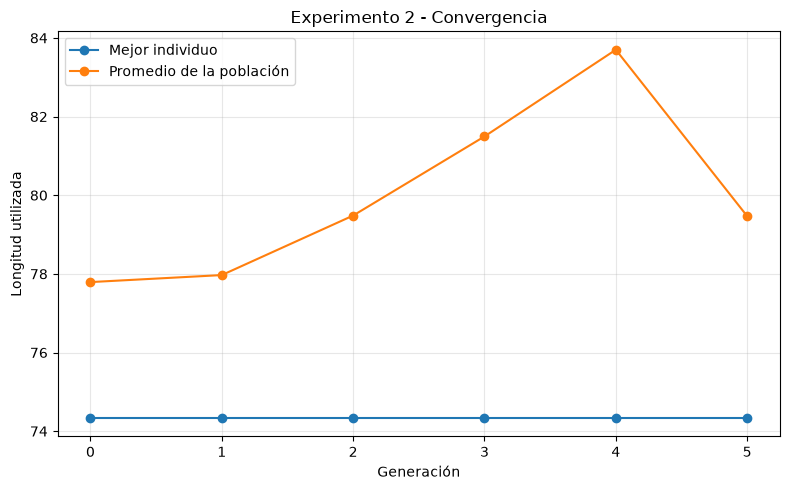

In [45]:
fig, ax = plot_experiment_history(
    history=experiment_2_history,
    title="Experimento 2 - Convergencia",
)

plt.show()

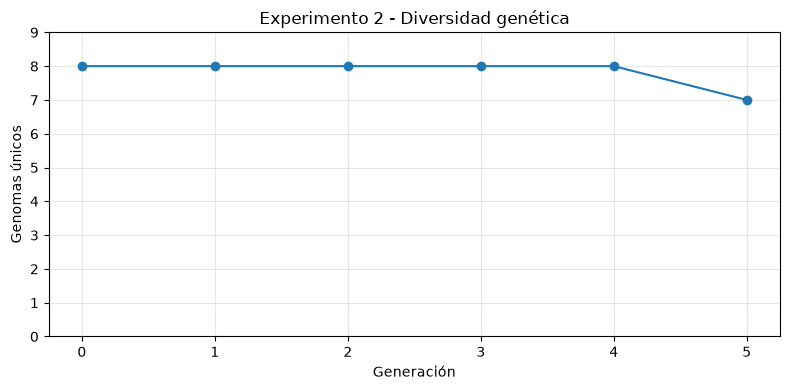

In [46]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.plot(
    experiment_2_history_df[
        "generation"
    ],
    experiment_2_history_df[
        "unique_genomes"
    ],
    marker="o",
)

ax.set_xlabel("Generación")
ax.set_ylabel("Genomas únicos")

ax.set_title(
    "Experimento 2 - Diversidad genética"
)

ax.set_ylim(
    0,
    experiment_2_params[
        "population_size"
    ] + 1,
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

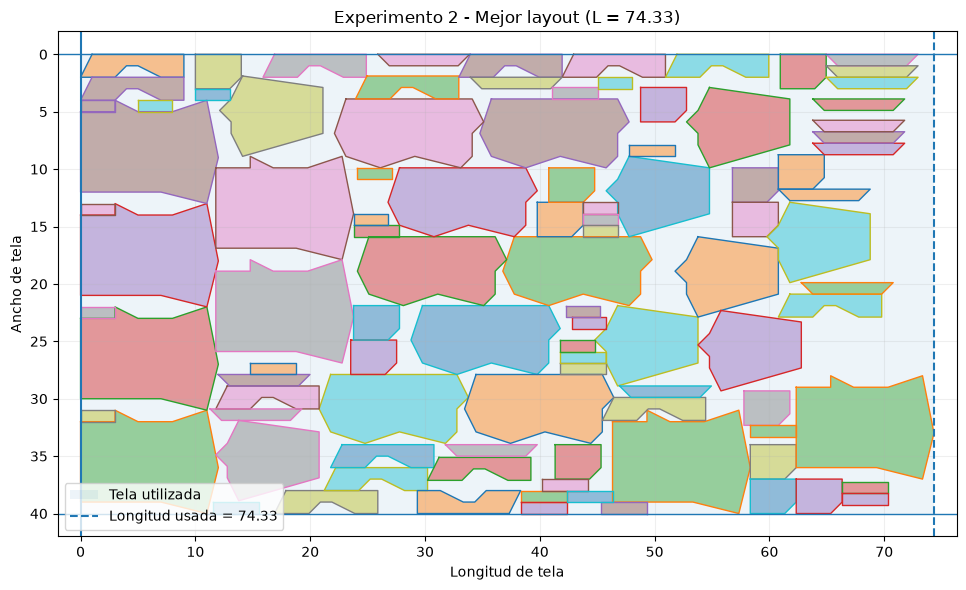

In [47]:
experiment_2_best_order, \
experiment_2_best_orientations = (
    split_individual(
        experiment_2_best,
        N_PIECES,
    )
)

experiment_2_best_result = (
    decode_solution(
        problem=problem,
        order=experiment_2_best_order,
        orientations=(
            experiment_2_best_orientations
        ),
    )
)

plot_layout(
    result=experiment_2_best_result,
    board_width=BOARD_WIDTH,
    title=(
        "Experimento 2 - Mejor layout "
        f"(L = "
        f"{experiment_2_best_result.used_length:.2f})"
    ),
    show_reference_points=False,
    show_instance_ids=False,
)

plt.show()

In [48]:
experiment_2_summary = (
    save_experiment_results(
        experiment_name="experiment_2",
        history=experiment_2_history,
        best_individual=(
            experiment_2_best
        ),
        parameters=(
            experiment_2_params
        ),
    )
)

experiment_2_summary

{'best_length': 74.33333334,
 'utilization_percent': 72.6457399037986,
 'layout_valid': True,
 'layout_errors': 0,
 'best_generation': 0,
 'final_unique_genomes': 7,
 'total_new_evaluations': 40,
 'total_time_s': 324.4098573000083}

### Análisis del Experimento 2

El aumento de diversidad inicial y de la tasa de mutación evita la convergencia prematura observada en el Experimento 1.

La población conserva prácticamente todos sus genotipos durante las cinco generaciones, demostrando una capacidad exploratoria considerablemente mayor.

La mejor solución obtenida alcanza una longitud aproximada de **74.33**, mejorando la solución semilla utilizada como punto de partida.

Sin embargo, el fitness promedio de la población tiende a empeorar en varias generaciones mientras el mejor individuo permanece protegido por elitismo. Esto sugiere que la configuración posee una capacidad de exploración elevada, pero que la mutación utilizada puede resultar demasiado agresiva para explotar eficientemente la región próxima a las mejores soluciones.

Por este motivo, en el Experimento 3 se conserva la estrategia de diversidad poblacional pero se reducen las probabilidades de mutación con el objetivo de lograr un mejor equilibrio entre **exploración y explotación**.

## 11. Experimento 3 — Equilibrio entre exploración y explotación

El Experimento 2 logró evitar la convergencia prematura y mantener una elevada diversidad poblacional. Sin embargo, la alta tasa de mutación produjo una exploración agresiva: el mejor individuo se mantuvo protegido por elitismo, mientras que el fitness promedio empeoró en varias generaciones.

En este tercer experimento se conserva la estrategia de población inicial diversificada, pero se reduce la intensidad de las perturbaciones y las probabilidades de mutación.

### Objetivo

Buscar un mejor equilibrio entre:

- **exploración**, manteniendo diversidad suficiente para visitar nuevas soluciones;
- **explotación**, realizando modificaciones más pequeñas alrededor de la mejor solución conocida.

La mejor solución del Experimento 2 se utiliza como nueva semilla.

### Configuración

- población: 8 individuos;
- selección por torneo de tamaño 2;
- crossover: 0.8;
- mutación global: 0.5;
- mutación interna del orden: 0.025;
- mutación interna de orientación: 0.025;
- elitismo: 1 individuo;
- generaciones: 6;
- semilla aleatoria: 123.

In [49]:
experiment_3_seed_genome = list(
    experiment_2_best
)

experiment_3_seed_fitness = (
    experiment_2_best
    .fitness
    .values[0]
)

print(
    "Seed del Experimento 3:",
    f"{experiment_3_seed_fitness:.2f}",
)

print(
    "Seed válido:",
    validate_genome(
        problem,
        experiment_3_seed_genome,
    )[0],
)

Seed del Experimento 3: 74.33
Seed válido: True


In [50]:
experiment_3_params = {
    "seed": 123,
    "population_size": 8,
    "n_generations": 6,
    "tournament_size": 2,
    "crossover_probability": 0.8,
    "mutation_probability": 0.5,
    "order_indpb": 0.025,
    "orientation_indpb": 0.025,
    "elite_size": 1,
    "initial_population": {
        "seed_individuals": 1,
        "soft_perturbations": 2,
        "medium_perturbations": 3,
        "strong_perturbations": 2,
    },
}

experiment_3_params

{'seed': 123,
 'population_size': 8,
 'n_generations': 6,
 'tournament_size': 2,
 'crossover_probability': 0.8,
 'mutation_probability': 0.5,
 'order_indpb': 0.025,
 'orientation_indpb': 0.025,
 'elite_size': 1,
 'initial_population': {'seed_individuals': 1,
  'soft_perturbations': 2,
  'medium_perturbations': 3,
  'strong_perturbations': 2}}

### Población inicial

La población se construye nuevamente alrededor de la mejor solución conocida, pero utilizando perturbaciones más suaves que en el Experimento 2.

Se generan:

- 1 copia del mejor individuo del Experimento 2;
- 2 perturbaciones suaves, con un intercambio de posiciones;
- 3 perturbaciones intermedias, con dos intercambios;
- 2 perturbaciones más fuertes, con cuatro intercambios.

Las probabilidades de modificación de orientación también se reducen.

El objetivo es conservar diversidad sin alejar excesivamente a la población de la región prometedora encontrada en el experimento anterior.

In [51]:
experiment_3_rng = random.Random(
    experiment_3_params["seed"]
)

experiment_3_genomes = [
    experiment_3_seed_genome.copy()
]

# --------------------------------------------------
# Perturbaciones suaves
# --------------------------------------------------

for _ in range(2):

    experiment_3_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=experiment_3_seed_genome,
            n_order_swaps=1,
            orientation_mutation_prob=0.01,
            rng=experiment_3_rng,
        )
    )

# --------------------------------------------------
# Perturbaciones intermedias
# --------------------------------------------------

for _ in range(3):

    experiment_3_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=experiment_3_seed_genome,
            n_order_swaps=2,
            orientation_mutation_prob=0.02,
            rng=experiment_3_rng,
        )
    )

# --------------------------------------------------
# Perturbaciones fuertes
# --------------------------------------------------

for _ in range(2):

    experiment_3_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=experiment_3_seed_genome,
            n_order_swaps=4,
            orientation_mutation_prob=0.04,
            rng=experiment_3_rng,
        )
    )

In [52]:
experiment_3_population = [
    create_deap_individual(genome)
    for genome in experiment_3_genomes
]

experiment_3_unique_initial = len({
    genome_key(individual)
    for individual
    in experiment_3_population
})

experiment_3_all_valid = all(
    validate_genome(
        problem,
        individual,
    )[0]
    for individual
    in experiment_3_population
)

print(
    "Tamaño de población:",
    len(experiment_3_population),
)

print(
    "Genomas únicos:",
    experiment_3_unique_initial,
)

print(
    "Todos válidos:",
    experiment_3_all_valid,
)

Tamaño de población: 8
Genomas únicos: 8
Todos válidos: True


In [53]:
random.seed(
    experiment_3_params["seed"]
)

experiment_3_cache = {}

experiment_3_toolbox = create_toolbox(
    problem=problem,
    cache=experiment_3_cache,
    tournament_size=(
        experiment_3_params[
            "tournament_size"
        ]
    ),
    order_indpb=(
        experiment_3_params[
            "order_indpb"
        ]
    ),
    orientation_indpb=(
        experiment_3_params[
            "orientation_indpb"
        ]
    ),
)

In [54]:
experiment_3_population_final, \
experiment_3_best, \
experiment_3_history = (
    run_genetic_algorithm(
        population=(
            experiment_3_population
        ),
        toolbox=(
            experiment_3_toolbox
        ),
        cache=(
            experiment_3_cache
        ),
        n_generations=(
            experiment_3_params[
                "n_generations"
            ]
        ),
        crossover_probability=(
            experiment_3_params[
                "crossover_probability"
            ]
        ),
        mutation_probability=(
            experiment_3_params[
                "mutation_probability"
            ]
        ),
        elite_size=(
            experiment_3_params[
                "elite_size"
            ]
        ),
    )
)

Generación 01 | best=74.33 | mean=79.27 | diversidad=8 | evals nuevas=7 | tiempo=58.14 s
Generación 02 | best=73.78 | mean=77.74 | diversidad=7 | evals nuevas=4 | tiempo=32.08 s
Generación 03 | best=73.78 | mean=76.85 | diversidad=8 | evals nuevas=6 | tiempo=51.55 s
Generación 04 | best=73.78 | mean=78.66 | diversidad=8 | evals nuevas=6 | tiempo=49.20 s
Generación 05 | best=73.78 | mean=79.47 | diversidad=8 | evals nuevas=6 | tiempo=57.42 s
Generación 06 | best=73.78 | mean=78.25 | diversidad=8 | evals nuevas=6 | tiempo=47.74 s


In [55]:
experiment_3_history_df = pd.DataFrame(
    experiment_3_history
)

experiment_3_history_df

,generation,best,mean,worst,new_evaluations,unique_genomes,elapsed_time
0,0,74.333333,78.836111,82.777778,8,8,66.360360
1,1,74.333333,79.269841,85.111111,7,8,58.144532
2,2,73.777778,77.743983,85.174085,4,7,32.078001
3,3,73.777778,76.848380,81.000000,6,8,51.552561
4,4,73.777778,78.658900,84.777778,6,8,49.201867
5,5,73.777778,79.472500,84.000000,6,8,57.422694
6,6,73.777778,78.251667,81.280000,6,8,47.742101


In [56]:
experiment_3_best_length = (
    experiment_3_best
    .fitness
    .values[0]
)

experiment_3_unique_final = len({
    genome_key(individual)
    for individual
    in experiment_3_population_final
})

experiment_3_improvement = (
    (
        experiment_3_seed_fitness
        - experiment_3_best_length
    )
    / experiment_3_seed_fitness
    * 100
)

print(
    "Seed inicial:",
    f"{experiment_3_seed_fitness:.2f}",
)

print(
    "Mejor longitud:",
    f"{experiment_3_best_length:.2f}",
)

print(
    "Mejora respecto del seed:",
    f"{experiment_3_improvement:.2f}%",
)

print(
    "Genomas únicos finales:",
    experiment_3_unique_final,
)

Seed inicial: 74.33
Mejor longitud: 73.78
Mejora respecto del seed: 0.75%
Genomas únicos finales: 8


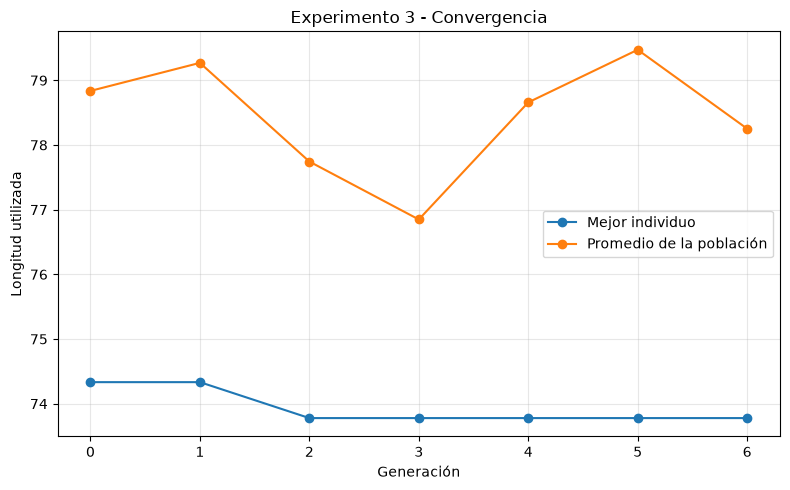

In [57]:
fig, ax = plot_experiment_history(
    history=experiment_3_history,
    title="Experimento 3 - Convergencia",
)

plt.show()

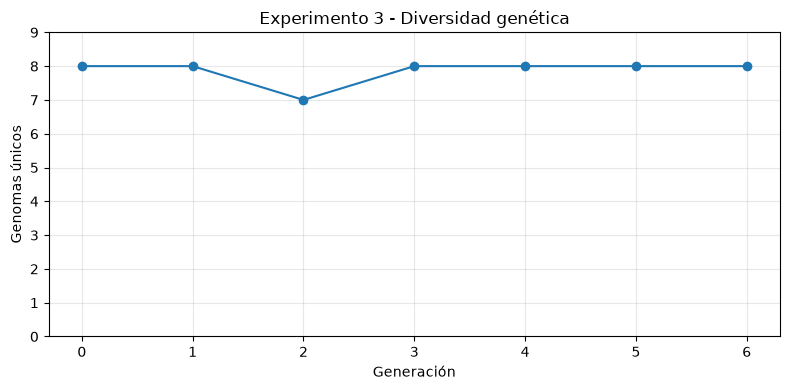

In [58]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.plot(
    experiment_3_history_df[
        "generation"
    ],
    experiment_3_history_df[
        "unique_genomes"
    ],
    marker="o",
)

ax.set_xlabel(
    "Generación"
)

ax.set_ylabel(
    "Genomas únicos"
)

ax.set_title(
    "Experimento 3 - Diversidad genética"
)

ax.set_ylim(
    0,
    experiment_3_params[
        "population_size"
    ] + 1,
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
experiment_3_best_order, \
experiment_3_best_orientations = (
    split_individual(
        experiment_3_best,
        N_PIECES,
    )
)

experiment_3_best_result = (
    decode_solution(
        problem=problem,
        order=experiment_3_best_order,
        orientations=(
            experiment_3_best_orientations
        ),
    )
)

In [60]:
experiment_3_layout_valid, \
experiment_3_layout_errors = (
    validate_layout(
        board_geometry=(
            problem.board_geometry
        ),
        geometries=[
            placement.geometry
            for placement
            in experiment_3_best_result.placements
        ],
    )
)

print(
    "Longitud:",
    f"{experiment_3_best_result.used_length:.4f}",
)

print(
    "Piezas colocadas:",
    len(
        experiment_3_best_result.placements
    ),
)

print(
    "Layout válido:",
    experiment_3_layout_valid,
)

print(
    "Errores:",
    len(experiment_3_layout_errors),
)

Longitud: 73.7778
Piezas colocadas: 99
Layout válido: True
Errores: 0


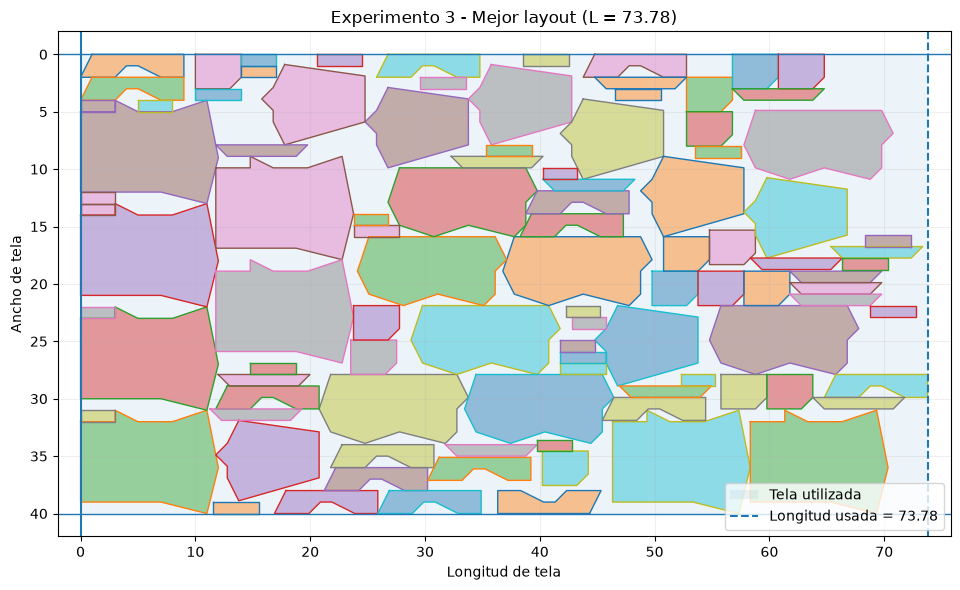

In [61]:
plot_layout(
    result=experiment_3_best_result,
    board_width=BOARD_WIDTH,
    title=(
        "Experimento 3 - Mejor layout "
        f"(L = "
        f"{experiment_3_best_result.used_length:.2f})"
    ),
    show_reference_points=False,
    show_instance_ids=False,
)

plt.show()

In [62]:
experiment_3_utilization = (
    TOTAL_PIECE_AREA
    / (
        BOARD_WIDTH
        * experiment_3_best_result.used_length
    )
    * 100
)

experiment_3_waste = (
    100
    - experiment_3_utilization
)

print(
    "Aprovechamiento de material:",
    f"{experiment_3_utilization:.2f}%",
)

print(
    "Desperdicio:",
    f"{experiment_3_waste:.2f}%",
)

Aprovechamiento de material: 73.19%
Desperdicio: 26.81%


In [63]:
experiment_3_summary = (
    save_experiment_results(
        experiment_name="experiment_3",
        history=experiment_3_history,
        best_individual=(
            experiment_3_best
        ),
        parameters=(
            experiment_3_params
        ),
    )
)

experiment_3_summary

{'best_length': 73.77777778,
 'utilization_percent': 73.19277108213275,
 'layout_valid': True,
 'layout_errors': 0,
 'best_generation': 2,
 'final_unique_genomes': 8,
 'total_new_evaluations': 43,
 'total_time_s': 362.50211789999594}

### Análisis del Experimento 3

La reducción de las probabilidades de mutación permitió obtener un mejor equilibrio entre exploración y explotación.

A diferencia del Experimento 1, la población conserva una elevada diversidad durante toda la evolución. Al mismo tiempo, a diferencia del Experimento 2, la búsqueda logra explotar de forma más efectiva la región próxima a la mejor solución conocida.

Durante la segunda generación se obtiene una nueva mejora del fitness, alcanzando una longitud aproximada de **73.78**.

La solución permanece estable durante las generaciones siguientes y la población continúa presentando una elevada diversidad genética.

Por lo tanto, esta configuración proporciona el mejor resultado de los tres experimentos y se selecciona como configuración final del algoritmo.

## 12. Comparación de resultados

Una vez completados los tres experimentos, se comparan las soluciones obtenidas con las referencias iniciales.

Se consideran:

- **Baseline original:** orden natural de las piezas y orientación `0°`.
- **Heurística por área:** piezas ordenadas de mayor a menor área.
- **Seed inicial:** mejor perturbación encontrada alrededor de la heurística.
- **Experimento 1:** configuración inicial con baja diversidad.
- **Experimento 2:** incremento de diversidad y exploración.
- **Experimento 3:** configuración más equilibrada entre exploración y explotación.

La comparación se realiza utilizando como métrica principal la longitud de tela utilizada. También se calcula el porcentaje de aprovechamiento del material y la mejora relativa respecto del baseline original.

In [64]:
seed_utilization = (
    TOTAL_PIECE_AREA
    / (
        BOARD_WIDTH
        * best_seed_fitness
    )
    * 100
)

experiment_1_length = (
    experiment_1_summary["best_length"]
)

experiment_2_length = (
    experiment_2_summary["best_length"]
)

experiment_3_length = (
    experiment_3_summary["best_length"]
)

In [65]:
comparison_rows = [
    {
        "solution": "Baseline original",
        "best_length": baseline_length,
        "utilization_percent": baseline_utilization,
        "best_generation": None,
        "final_unique_genomes": None,
    },
    {
        "solution": "Heurística por área",
        "best_length": area_length,
        "utilization_percent": area_utilization,
        "best_generation": None,
        "final_unique_genomes": None,
    },
    {
        "solution": "Seed inicial",
        "best_length": best_seed_fitness,
        "utilization_percent": seed_utilization,
        "best_generation": None,
        "final_unique_genomes": None,
    },
    {
        "solution": "Experimento 1",
        "best_length": experiment_1_length,
        "utilization_percent": (
            experiment_1_summary[
                "utilization_percent"
            ]
        ),
        "best_generation": (
            experiment_1_summary[
                "best_generation"
            ]
        ),
        "final_unique_genomes": (
            experiment_1_summary[
                "final_unique_genomes"
            ]
        ),
    },
    {
        "solution": "Experimento 2",
        "best_length": experiment_2_length,
        "utilization_percent": (
            experiment_2_summary[
                "utilization_percent"
            ]
        ),
        "best_generation": (
            experiment_2_summary[
                "best_generation"
            ]
        ),
        "final_unique_genomes": (
            experiment_2_summary[
                "final_unique_genomes"
            ]
        ),
    },
    {
        "solution": "Experimento 3",
        "best_length": experiment_3_length,
        "utilization_percent": (
            experiment_3_summary[
                "utilization_percent"
            ]
        ),
        "best_generation": (
            experiment_3_summary[
                "best_generation"
            ]
        ),
        "final_unique_genomes": (
            experiment_3_summary[
                "final_unique_genomes"
            ]
        ),
    },
]

comparison_df = pd.DataFrame(
    comparison_rows
)

In [66]:
comparison_df[
    "improvement_vs_baseline_percent"
] = (
    (
        baseline_length
        - comparison_df["best_length"]
    )
    / baseline_length
    * 100
)

comparison_df

,solution,best_length,utilization_percent,best_generation,final_unique_genomes,improvement_vs_baseline_percent
0,Baseline original,79.500000,67.924528,NaN,NaN,0.000000
1,Heurística por área,76.944444,70.180505,NaN,NaN,3.214535
2,Seed inicial,74.777778,72.213967,NaN,NaN,5.939902
3,Experimento 1,74.777778,72.213967,0.0,1.0,5.939902
4,Experimento 2,74.333333,72.645740,0.0,7.0,6.498952
5,Experimento 3,73.777778,73.192771,2.0,8.0,7.197764


In [67]:
comparison_df.to_csv(
    RESULTS_DIR
    / "experiments_summary.csv",
    index=False,
)

## 13. Comparación de convergencia

Las curvas de convergencia permiten observar cómo las distintas configuraciones afectan la búsqueda.

El primer experimento pierde rápidamente diversidad y converge hacia la solución semilla. En el segundo se incrementa la exploración, mientras que el tercero utiliza una configuración de mutación más moderada para explotar mejor las regiones prometedoras del espacio de búsqueda.

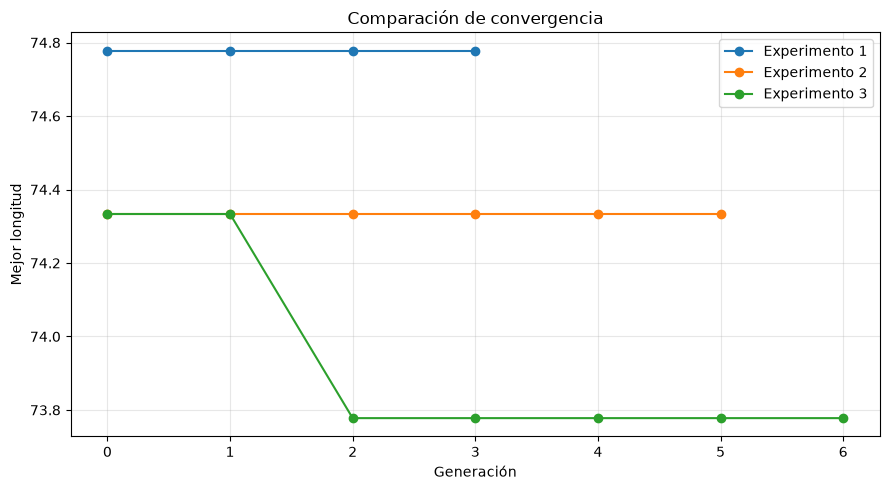

In [68]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

for history_df, label in [
    (
        experiment_1_history_df,
        "Experimento 1",
    ),
    (
        experiment_2_history_df,
        "Experimento 2",
    ),
    (
        experiment_3_history_df,
        "Experimento 3",
    ),
]:

    ax.plot(
        history_df["generation"],
        history_df["best"],
        marker="o",
        label=label,
    )

ax.set_xlabel(
    "Generación"
)

ax.set_ylabel(
    "Mejor longitud"
)

ax.set_title(
    "Comparación de convergencia"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "experiments_convergence_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

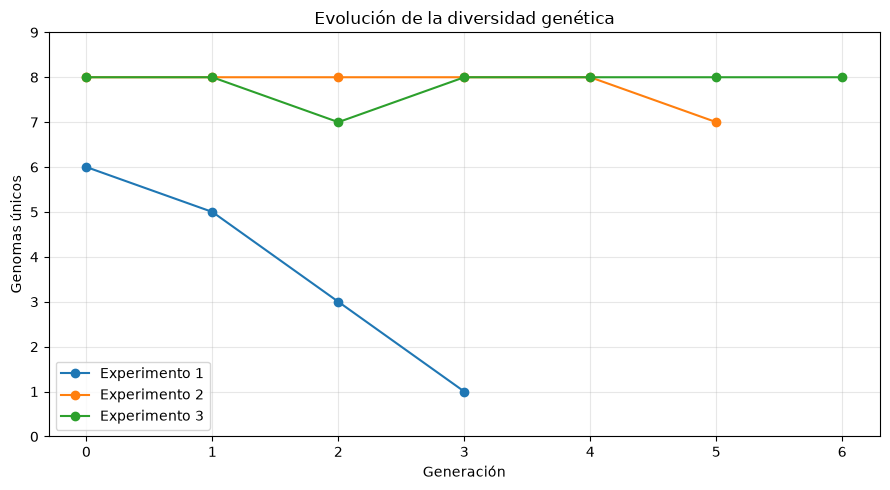

In [69]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

for history_df, label in [
    (
        experiment_1_history_df,
        "Experimento 1",
    ),
    (
        experiment_2_history_df,
        "Experimento 2",
    ),
    (
        experiment_3_history_df,
        "Experimento 3",
    ),
]:

    ax.plot(
        history_df["generation"],
        history_df["unique_genomes"],
        marker="o",
        label=label,
    )

ax.set_xlabel(
    "Generación"
)

ax.set_ylabel(
    "Genomas únicos"
)

ax.set_title(
    "Evolución de la diversidad genética"
)

ax.set_ylim(
    0,
    9,
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "experiments_diversity_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 15. Mejor solución obtenida

Entre todas las configuraciones evaluadas, el Experimento 3 produce la menor longitud de tela utilizada.

La solución final se reconstruye nuevamente mediante el decoder y se verifica geométricamente para asegurar que:

- las 99 piezas se encuentren dentro del tablero;
- no existan solapamientos con área positiva;
- las orientaciones utilizadas sean válidas.

Finalmente se calcula el porcentaje de aprovechamiento del material y la mejora relativa respecto del baseline original.

In [70]:
final_best_genome = [
    int(gene)
    for gene in experiment_3_best
]

final_order, final_orientations = (
    split_individual(
        final_best_genome,
        N_PIECES,
    )
)

final_result = decode_solution(
    problem=problem,
    order=final_order,
    orientations=final_orientations,
)

final_geometries = [
    placement.geometry
    for placement
    in final_result.placements
]

final_valid, final_errors = (
    validate_layout(
        board_geometry=(
            problem.board_geometry
        ),
        geometries=final_geometries,
    )
)

In [71]:
final_length = (
    final_result.used_length
)

final_utilization = (
    TOTAL_PIECE_AREA
    / (
        BOARD_WIDTH
        * final_length
    )
    * 100
)

final_improvement = (
    (
        baseline_length
        - final_length
    )
    / baseline_length
    * 100
)

final_gap_to_area_bound = (
    (
        final_length
        - AREA_LOWER_BOUND
    )
    / AREA_LOWER_BOUND
    * 100
)

print(
    "Longitud final:",
    f"{final_length:.4f}",
)

print(
    "Piezas colocadas:",
    len(final_result.placements),
)

print(
    "Layout válido:",
    final_valid,
)

print(
    "Errores geométricos:",
    len(final_errors),
)

print(
    "Aprovechamiento:",
    f"{final_utilization:.2f}%",
)

print(
    "Mejora vs. baseline:",
    f"{final_improvement:.2f}%",
)

print(
    "Cota inferior por área:",
    f"{AREA_LOWER_BOUND:.2f}",
)

Longitud final: 73.7778
Piezas colocadas: 99
Layout válido: True
Errores geométricos: 0
Aprovechamiento: 73.19%
Mejora vs. baseline: 7.20%
Cota inferior por área: 54.00


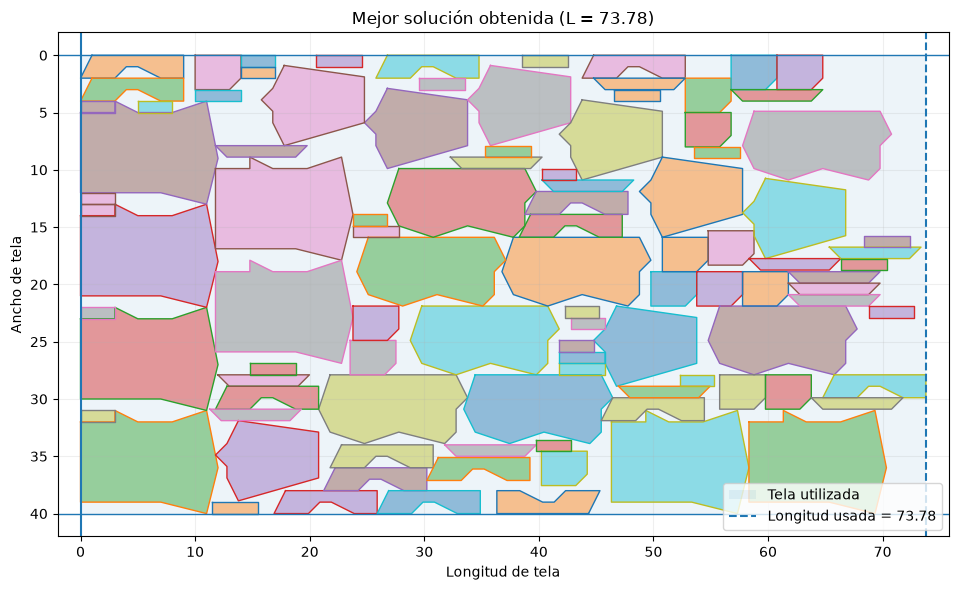

In [72]:
fig, ax = plot_layout(
    result=final_result,
    board_width=BOARD_WIDTH,
    title=(
        "Mejor solución obtenida "
        f"(L = {final_length:.2f})"
    ),
    show_reference_points=False,
    show_instance_ids=False,
)

fig.savefig(
    FIGURES_DIR
    / "best_layout_final.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [73]:
final_solution = {
    "best_length": float(
        final_length
    ),
    "utilization_percent": float(
        final_utilization
    ),
    "improvement_vs_baseline_percent": float(
        final_improvement
    ),
    "layout_valid": bool(
        final_valid
    ),
    "number_of_pieces": int(
        len(final_result.placements)
    ),
    "area_lower_bound": float(
        AREA_LOWER_BOUND
    ),
    "genome": final_best_genome,
}

with open(
    RESULTS_DIR
    / "best_solution.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_solution,
        file,
        indent=2,
    )

## 12. Experimento 4 — Extensión del presupuesto de búsqueda

El Experimento 3 produjo la mejor solución de las configuraciones
evaluadas, alcanzando una longitud de aproximadamente 73.78 en la
segunda generación. Sin embargo, no se observaron nuevas mejoras
durante las generaciones restantes.

Para evaluar si este comportamiento se debía al reducido presupuesto
computacional, se realizó una corrida adicional conservando los
parámetros de crossover y mutación del Experimento 3, pero aumentando
el tamaño de la población y la cantidad de generaciones.

De esta manera se busca analizar si una búsqueda más prolongada permite
escapar de la solución encontrada o si el algoritmo permanece en una
región de calidad similar.

### Configuración

- población: 15 individuos;
- generaciones: 25;
- torneo: 2;
- crossover: 0.80;
- mutación global: 0.50;
- mutación interna del orden: 0.025;
- mutación interna de orientación: 0.025;
- elitismo: 1 individuo.

La mejor solución del Experimento 3 se utiliza como punto de partida.

In [74]:
experiment_4_params = {
    "seed": 456,
    "population_size": 15,
    "n_generations": 25,
    "tournament_size": 2,
    "crossover_probability": 0.80,
    "mutation_probability": 0.50,
    "order_indpb": 0.025,
    "orientation_indpb": 0.025,
    "elite_size": 1,
}

In [75]:
experiment_4_seed_genome = list(
    experiment_3_best
)

experiment_4_seed_fitness = (
    experiment_3_best
    .fitness
    .values[0]
)

print(
    "Seed del Experimento 4:",
    f"{experiment_4_seed_fitness:.4f}",
)

Seed del Experimento 4: 73.7778


In [76]:
experiment_4_rng = random.Random(
    experiment_4_params["seed"]
)

experiment_4_genomes = [
    experiment_4_seed_genome.copy()
]

# 4 perturbaciones suaves
for _ in range(4):
    experiment_4_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=experiment_4_seed_genome,
            n_order_swaps=1,
            orientation_mutation_prob=0.01,
            rng=experiment_4_rng,
        )
    )

# 6 perturbaciones intermedias
for _ in range(6):
    experiment_4_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=experiment_4_seed_genome,
            n_order_swaps=2,
            orientation_mutation_prob=0.02,
            rng=experiment_4_rng,
        )
    )

# 4 perturbaciones más fuertes
for _ in range(4):
    experiment_4_genomes.append(
        create_perturbed_genome(
            problem=problem,
            base_genome=experiment_4_seed_genome,
            n_order_swaps=4,
            orientation_mutation_prob=0.04,
            rng=experiment_4_rng,
        )
    )

In [77]:
experiment_4_population = [
    create_deap_individual(genome)
    for genome in experiment_4_genomes
]

In [78]:
experiment_4_unique_initial = len({
    genome_key(individual)
    for individual in experiment_4_population
})

experiment_4_all_valid = all(
    validate_genome(
        problem,
        individual,
    )[0]
    for individual
    in experiment_4_population
)

print(
    "Tamaño de población:",
    len(experiment_4_population),
)

print(
    "Genomas únicos:",
    experiment_4_unique_initial,
)

print(
    "Todos válidos:",
    experiment_4_all_valid,
)

Tamaño de población: 15
Genomas únicos: 15
Todos válidos: True


In [79]:
random.seed(
    experiment_4_params["seed"]
)

experiment_4_cache = {}

experiment_4_toolbox = create_toolbox(
    problem=problem,
    cache=experiment_4_cache,
    tournament_size=(
        experiment_4_params[
            "tournament_size"
        ]
    ),
    order_indpb=(
        experiment_4_params[
            "order_indpb"
        ]
    ),
    orientation_indpb=(
        experiment_4_params[
            "orientation_indpb"
        ]
    ),
)

In [80]:
experiment_4_population_final, \
experiment_4_best, \
experiment_4_history = (
    run_genetic_algorithm(
        population=experiment_4_population,
        toolbox=experiment_4_toolbox,
        cache=experiment_4_cache,
        n_generations=(
            experiment_4_params[
                "n_generations"
            ]
        ),
        crossover_probability=(
            experiment_4_params[
                "crossover_probability"
            ]
        ),
        mutation_probability=(
            experiment_4_params[
                "mutation_probability"
            ]
        ),
        elite_size=(
            experiment_4_params[
                "elite_size"
            ]
        ),
    )
)

Generación 01 | best=73.78 | mean=77.73 | diversidad=14 | evals nuevas=12 | tiempo=95.51 s
Generación 02 | best=73.78 | mean=77.81 | diversidad=15 | evals nuevas=11 | tiempo=92.22 s
Generación 03 | best=73.78 | mean=79.06 | diversidad=14 | evals nuevas=10 | tiempo=85.18 s
Generación 04 | best=73.78 | mean=80.13 | diversidad=15 | evals nuevas=14 | tiempo=132.27 s
Generación 05 | best=73.78 | mean=82.95 | diversidad=15 | evals nuevas=14 | tiempo=144.13 s
Generación 06 | best=73.78 | mean=83.48 | diversidad=15 | evals nuevas=12 | tiempo=136.84 s
Generación 07 | best=73.78 | mean=82.56 | diversidad=14 | evals nuevas=13 | tiempo=146.89 s
Generación 08 | best=73.78 | mean=82.81 | diversidad=14 | evals nuevas=12 | tiempo=138.29 s
Generación 09 | best=73.78 | mean=80.33 | diversidad=14 | evals nuevas=11 | tiempo=122.33 s
Generación 10 | best=73.78 | mean=82.12 | diversidad=15 | evals nuevas=14 | tiempo=147.00 s
Generación 11 | best=73.78 | mean=82.63 | diversidad=15 | evals nuevas=13 | tiempo=

In [81]:
experiment_4_history_df = pd.DataFrame(
    experiment_4_history
)

experiment_4_history_df

,generation,best,mean,worst,new_evaluations,unique_genomes,elapsed_time
0,0,73.777778,77.453330,82.507778,15,15,119.886055
1,1,73.777778,77.732494,84.430000,12,14,95.514569
2,2,73.777778,77.814533,81.367725,11,15,92.221342
3,3,73.777778,79.062670,85.777778,10,14,85.184672
4,4,73.777778,80.132886,94.000000,14,15,132.271150
5,5,73.777778,82.950035,91.350000,14,15,144.130360
6,6,73.777778,83.481473,92.000000,12,15,136.841081
7,7,73.777778,82.556019,96.000000,13,14,146.887873
8,8,73.777778,82.809398,102.500000,12,14,138.289978
9,9,73.777778,80.328201,90.777778,11,14,122.334113


In [82]:
experiment_4_best_length = (
    experiment_4_best
    .fitness
    .values[0]
)

experiment_4_best_generation = (
    experiment_4_history_df
    .loc[
        experiment_4_history_df["best"].idxmin(),
        "generation",
    ]
)

experiment_4_total_time = (
    experiment_4_history_df[
        "elapsed_time"
    ].sum()
)

experiment_4_unique_final = len({
    genome_key(individual)
    for individual
    in experiment_4_population_final
})

print(
    "Seed inicial:",
    f"{experiment_4_seed_fitness:.4f}",
)

print(
    "Mejor longitud:",
    f"{experiment_4_best_length:.4f}",
)

print(
    "Generación del mejor:",
    experiment_4_best_generation,
)

print(
    "Genomas únicos finales:",
    experiment_4_unique_final,
)

print(
    "Tiempo total:",
    f"{experiment_4_total_time / 60:.1f} min",
)

Seed inicial: 73.7778
Mejor longitud: 72.2778
Generación del mejor: 13
Genomas únicos finales: 15
Tiempo total: 53.3 min


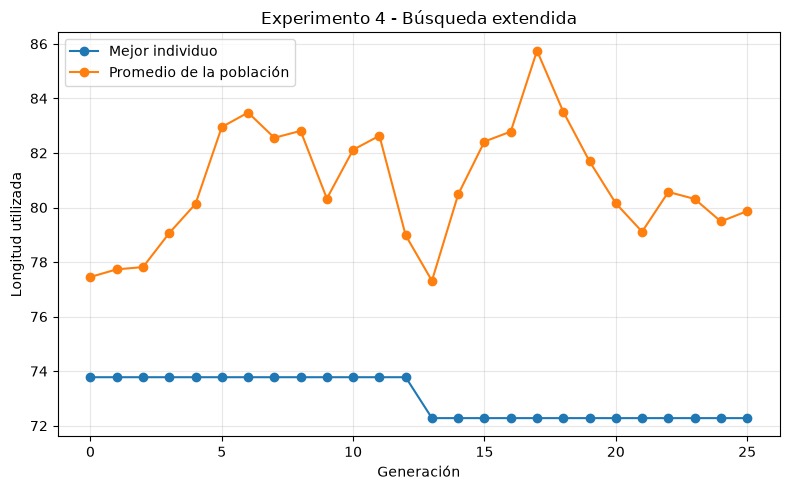

In [83]:
fig, ax = plot_experiment_history(
    history=experiment_4_history,
    title="Experimento 4 - Búsqueda extendida",
)

plt.show()

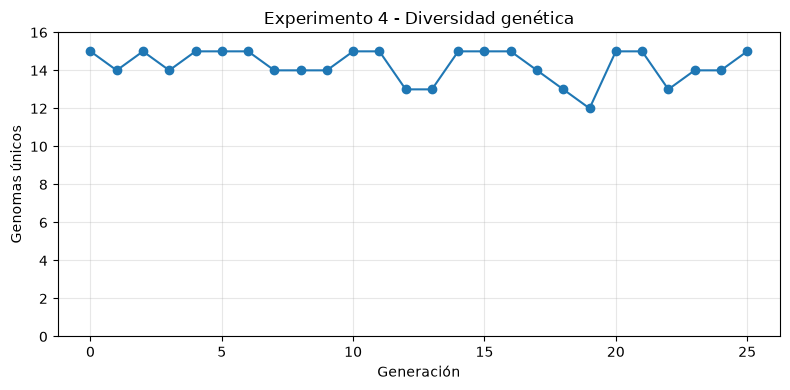

In [84]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.plot(
    experiment_4_history_df["generation"],
    experiment_4_history_df["unique_genomes"],
    marker="o",
)

ax.set_xlabel("Generación")
ax.set_ylabel("Genomas únicos")

ax.set_title(
    "Experimento 4 - Diversidad genética"
)

ax.set_ylim(
    0,
    experiment_4_params[
        "population_size"
    ] + 1,
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
experiment_4_summary = (
    save_experiment_results(
        experiment_name="experiment_4",
        history=experiment_4_history,
        best_individual=experiment_4_best,
        parameters=experiment_4_params,
    )
)

experiment_4_summary

{'best_length': 72.27777778000001,
 'utilization_percent': 74.7117601821764,
 'layout_valid': True,
 'layout_errors': 0,
 'best_generation': 13,
 'final_unique_genomes': 15,
 'total_new_evaluations': 313,
 'total_time_s': 3197.227511799989}

In [86]:
extended_comparison = pd.DataFrame(
    [
        {
            "experiment": "Experimento 3",
            "best_length": (
                experiment_3_best
                .fitness
                .values[0]
            ),
        },
        {
            "experiment": "Experimento 4",
            "best_length": (
                experiment_4_best
                .fitness
                .values[0]
            ),
        },
    ]
)

extended_comparison

,experiment,best_length
0,Experimento 3,73.777778
1,Experimento 4,72.277778


In [87]:
best_extended_row = (
    extended_comparison
    .loc[
        extended_comparison[
            "best_length"
        ].idxmin()
    ]
)

print(
    "Mejor experimento:",
    best_extended_row["experiment"],
)

print(
    "Mejor longitud:",
    f"{best_extended_row['best_length']:.4f}",
)

Mejor experimento: Experimento 4
Mejor longitud: 72.2778


In [88]:
experiment_4_improvement_vs_seed = (
    (
        experiment_4_seed_fitness
        - experiment_4_best_length
    )
    / experiment_4_seed_fitness
    * 100
)

experiment_4_improved = (
    experiment_4_best_length
    < experiment_4_seed_fitness - 1e-8
)

print(
    "Seed inicial:",
    f"{experiment_4_seed_fitness:.4f}",
)

print(
    "Mejor longitud:",
    f"{experiment_4_best_length:.4f}",
)

print(
    "Generación del mejor:",
    experiment_4_best_generation,
)

print(
    "Mejora respecto del seed:",
    f"{experiment_4_improvement_vs_seed:.2f}%",
)

print(
    "Evaluaciones nuevas:",
    experiment_4_history_df[
        "new_evaluations"
    ].sum(),
)

print(
    "Tiempo total:",
    f"{experiment_4_total_time / 60:.1f} min",
)

print(
    "Diversidad final:",
    experiment_4_unique_final,
)

print(
    "¿Mejoró respecto del Exp. 3?:",
    experiment_4_improved,
)

Seed inicial: 73.7778
Mejor longitud: 72.2778
Generación del mejor: 13
Mejora respecto del seed: 2.03%
Evaluaciones nuevas: 313
Tiempo total: 53.3 min
Diversidad final: 15
¿Mejoró respecto del Exp. 3?: True


In [89]:
experiment_1_history_df = pd.read_csv(
    RESULTS_DIR
    / "experiment_1"
    / "history.csv"
)

experiment_2_history_df = pd.read_csv(
    RESULTS_DIR
    / "experiment_2"
    / "history.csv"
)

experiment_3_history_df = pd.read_csv(
    RESULTS_DIR
    / "experiment_3"
    / "history.csv"
)

experiment_4_history_df = pd.read_csv(
    RESULTS_DIR
    / "experiment_4"
    / "history.csv"
)

print(
    "Historiales cargados:",
    len(experiment_1_history_df),
    len(experiment_2_history_df),
    len(experiment_3_history_df),
    len(experiment_4_history_df),
)

Historiales cargados: 4 6 7 26


In [90]:
with open(
    RESULTS_DIR
    / "experiment_3"
    / "summary.json",
    "r",
    encoding="utf-8",
) as file:

    experiment_3_summary = json.load(file)

In [91]:
budget_comparison_df = pd.DataFrame(
    [
        {
            "experiment": "Experimento 3",
            "population": 8,
            "generations": 6,
            "best_length": (
                experiment_3_summary[
                    "best_length"
                ]
            ),
            "best_generation": (
                experiment_3_summary[
                    "best_generation"
                ]
            ),
            "new_evaluations": (
                experiment_3_summary[
                    "total_new_evaluations"
                ]
            ),
            "time_min": (
                experiment_3_summary[
                    "total_time_s"
                ]
                / 60
            ),
            "final_unique_genomes": (
                experiment_3_summary[
                    "final_unique_genomes"
                ]
            ),
        },
        {
            "experiment": "Experimento 4",
            "population": (
                experiment_4_params[
                    "population_size"
                ]
            ),
            "generations": (
                experiment_4_params[
                    "n_generations"
                ]
            ),
            "best_length": (
                experiment_4_summary[
                    "best_length"
                ]
            ),
            "best_generation": (
                experiment_4_summary[
                    "best_generation"
                ]
            ),
            "new_evaluations": (
                experiment_4_summary[
                    "total_new_evaluations"
                ]
            ),
            "time_min": (
                experiment_4_summary[
                    "total_time_s"
                ]
                / 60
            ),
            "final_unique_genomes": (
                experiment_4_summary[
                    "final_unique_genomes"
                ]
            ),
        },
    ]
)

budget_comparison_df.round(3)

,experiment,population,generations,best_length,best_generation,new_evaluations,time_min,final_unique_genomes
0,Experimento 3,8,6,73.778,2,43,6.042,8
1,Experimento 4,15,25,72.278,13,313,53.287,15


In [92]:
budget_comparison_df.to_csv(
    RESULTS_DIR
    / "experiment_3_vs_4.csv",
    index=False,
)

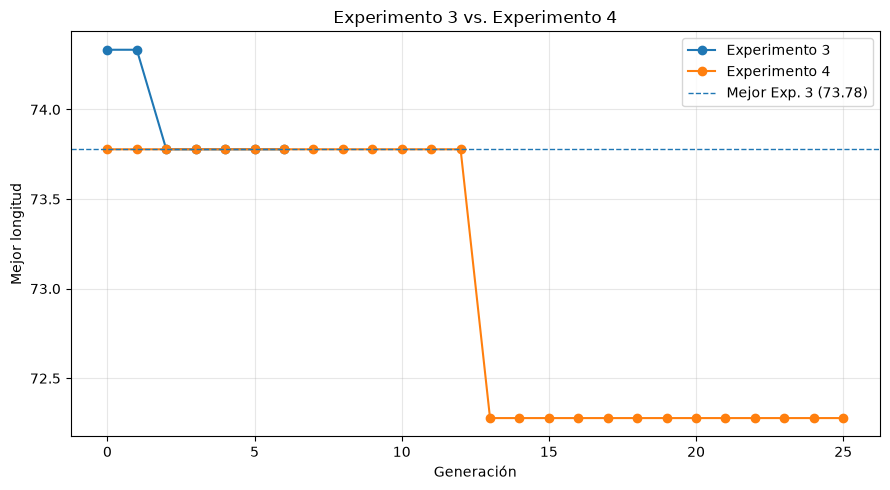

In [94]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    experiment_3_history_df[
        "generation"
    ],
    experiment_3_history_df[
        "best"
    ],
    marker="o",
    label="Experimento 3",
)

ax.plot(
    experiment_4_history_df[
        "generation"
    ],
    experiment_4_history_df[
        "best"
    ],
    marker="o",
    label="Experimento 4",
)

ax.axhline(
    experiment_4_seed_fitness,
    linestyle="--",
    linewidth=1,
    label=(
        "Mejor Exp. 3 "
        f"({experiment_4_seed_fitness:.2f})"
    ),
)

ax.set_xlabel(
    "Generación"
)

ax.set_ylabel(
    "Mejor longitud"
)

ax.set_title(
    "Experimento 3 vs. Experimento 4"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "experiment_3_vs_4_convergence.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

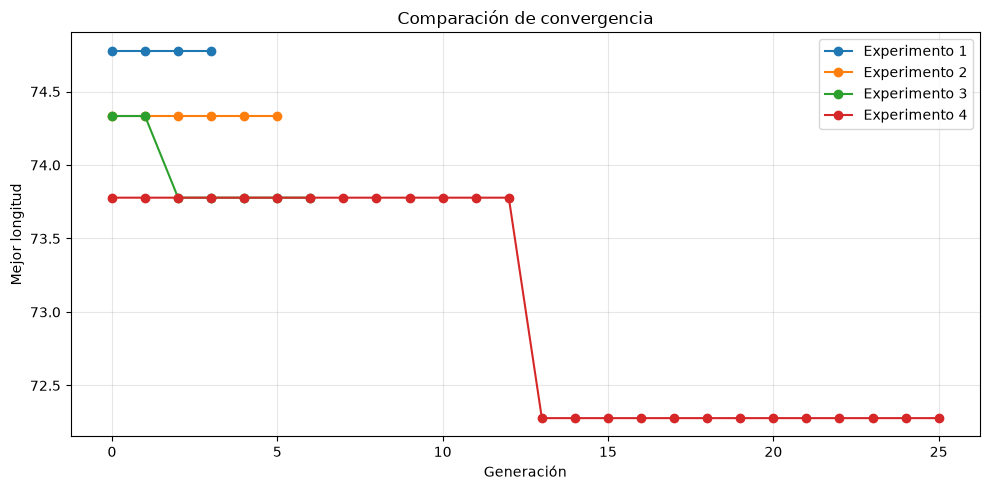

In [95]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for history_df, label in [
    (
        experiment_1_history_df,
        "Experimento 1",
    ),
    (
        experiment_2_history_df,
        "Experimento 2",
    ),
    (
        experiment_3_history_df,
        "Experimento 3",
    ),
    (
        experiment_4_history_df,
        "Experimento 4",
    ),
]:

    ax.plot(
        history_df["generation"],
        history_df["best"],
        marker="o",
        label=label,
    )

ax.set_xlabel(
    "Generación"
)

ax.set_ylabel(
    "Mejor longitud"
)

ax.set_title(
    "Comparación de convergencia"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "experiments_convergence_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

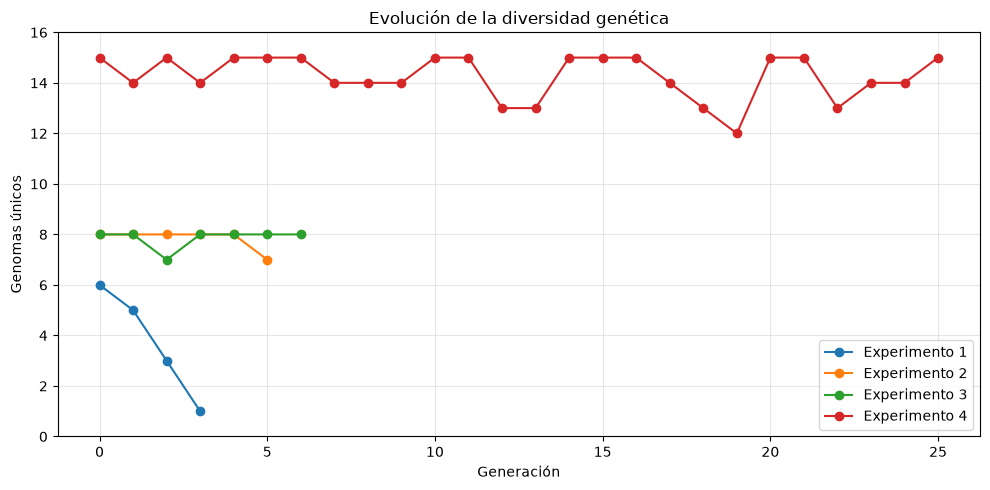

In [96]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for history_df, label in [
    (
        experiment_1_history_df,
        "Experimento 1",
    ),
    (
        experiment_2_history_df,
        "Experimento 2",
    ),
    (
        experiment_3_history_df,
        "Experimento 3",
    ),
    (
        experiment_4_history_df,
        "Experimento 4",
    ),
]:

    ax.plot(
        history_df["generation"],
        history_df["unique_genomes"],
        marker="o",
        label=label,
    )

ax.set_xlabel(
    "Generación"
)

ax.set_ylabel(
    "Genomas únicos"
)

ax.set_title(
    "Evolución de la diversidad genética"
)

ax.set_ylim(
    0,
    16,
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "experiments_diversity_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [98]:
comparison_df = pd.read_csv(
    RESULTS_DIR
    / "experiments_summary.csv"
)

# Por si se ejecuta esta celda más de una vez.
comparison_df = comparison_df[
    comparison_df["solution"]
    != "Experimento 4"
].copy()

baseline_length = float(
    comparison_df.loc[
        comparison_df["solution"]
        == "Baseline original",
        "best_length",
    ].iloc[0]
)

experiment_4_row = {
    "solution": "Experimento 4",
    "best_length": (
        experiment_4_summary[
            "best_length"
        ]
    ),
    "utilization_percent": (
        experiment_4_summary[
            "utilization_percent"
        ]
    ),
    "best_generation": (
        experiment_4_summary[
            "best_generation"
        ]
    ),
    "final_unique_genomes": (
        experiment_4_summary[
            "final_unique_genomes"
        ]
    ),
    "improvement_vs_baseline_percent": (
        (
            baseline_length
            - experiment_4_summary[
                "best_length"
            ]
        )
        / baseline_length
        * 100
    ),
}

comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame(
            [experiment_4_row]
        ),
    ],
    ignore_index=True,
)

comparison_df.round(3)

,solution,best_length,utilization_percent,best_generation,final_unique_genomes,improvement_vs_baseline_percent
0,Baseline original,79.500,67.925,NaN,NaN,0.000
1,Heurística por área,76.944,70.181,NaN,NaN,3.215
2,Seed inicial,74.778,72.214,NaN,NaN,5.940
3,Experimento 1,74.778,72.214,0.0,1.0,5.940
4,Experimento 2,74.333,72.646,0.0,7.0,6.499
5,Experimento 3,73.778,73.193,2.0,8.0,7.198
6,Experimento 4,72.278,74.712,13.0,15.0,9.085


In [99]:
comparison_df.to_csv(
    RESULTS_DIR
    / "experiments_summary.csv",
    index=False,
)

In [100]:
if (
    experiment_4_best_length
    < experiment_4_seed_fitness
):

    final_best_experiment = (
        "Experimento 4"
    )

    final_best_individual = (
        experiment_4_best
    )

else:

    final_best_experiment = (
        "Experimento 3"
    )

    final_best_individual = (
        experiment_3_best
    )


print(
    "Mejor experimento:",
    final_best_experiment,
)

print(
    "Mejor fitness:",
    f"{final_best_individual.fitness.values[0]:.4f}",
)

Mejor experimento: Experimento 4
Mejor fitness: 72.2778


In [101]:
final_best_genome = [
    int(gene)
    for gene
    in final_best_individual
]

final_order, final_orientations = (
    split_individual(
        final_best_genome,
        N_PIECES,
    )
)

final_result = decode_solution(
    problem=problem,
    order=final_order,
    orientations=final_orientations,
)

final_geometries = [
    placement.geometry
    for placement
    in final_result.placements
]

final_valid, final_errors = (
    validate_layout(
        board_geometry=(
            problem.board_geometry
        ),
        geometries=final_geometries,
    )
)

final_length = (
    final_result.used_length
)

final_utilization = (
    TOTAL_PIECE_AREA
    / (
        BOARD_WIDTH
        * final_length
    )
    * 100
)

final_improvement = (
    (
        baseline_length
        - final_length
    )
    / baseline_length
    * 100
)


print(
    "Experimento:",
    final_best_experiment,
)

print(
    "Longitud final:",
    f"{final_length:.4f}",
)

print(
    "Piezas colocadas:",
    len(final_result.placements),
)

print(
    "Layout válido:",
    final_valid,
)

print(
    "Errores:",
    len(final_errors),
)

print(
    "Aprovechamiento:",
    f"{final_utilization:.2f}%",
)

print(
    "Mejora vs baseline:",
    f"{final_improvement:.2f}%",
)

Experimento: Experimento 4
Longitud final: 72.2778
Piezas colocadas: 99
Layout válido: True
Errores: 0
Aprovechamiento: 74.71%
Mejora vs baseline: 9.08%


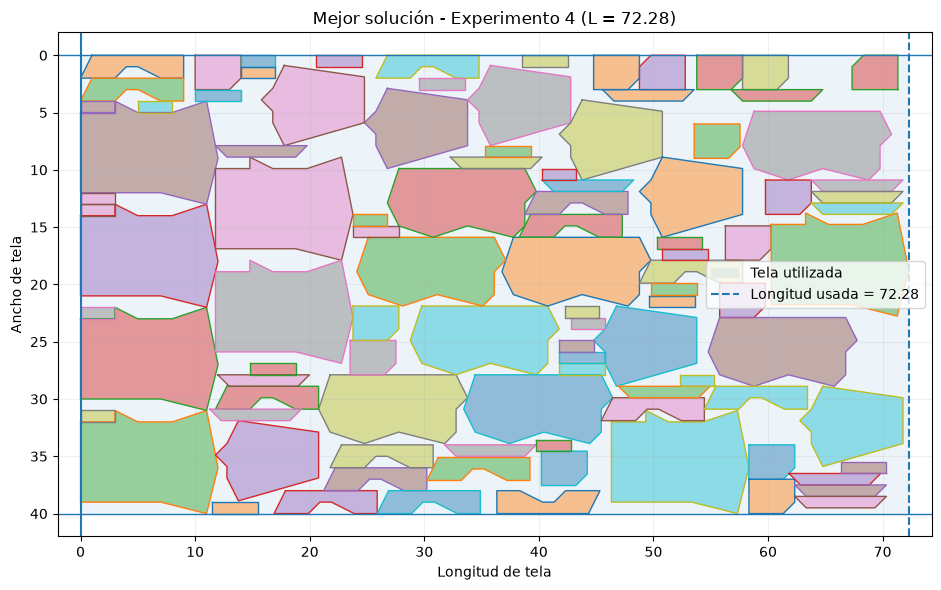

In [103]:
fig, ax = plot_layout(
    result=final_result,
    board_width=BOARD_WIDTH,
    title=(
        f"Mejor solución - "
        f"{final_best_experiment} "
        f"(L = {final_length:.2f})"
    ),
    show_reference_points=False,
    show_instance_ids=False,
)

fig.savefig(
    FIGURES_DIR
    / "best_layout_final.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [104]:
final_solution = {
    "best_experiment": (
        final_best_experiment
    ),
    "best_length": float(
        final_length
    ),
    "utilization_percent": float(
        final_utilization
    ),
    "improvement_vs_baseline_percent": float(
        final_improvement
    ),
    "layout_valid": bool(
        final_valid
    ),
    "number_of_pieces": int(
        len(final_result.placements)
    ),
    "area_lower_bound": float(
        AREA_LOWER_BOUND
    ),
    "genome": (
        final_best_genome
    ),
}

with open(
    RESULTS_DIR
    / "best_solution.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_solution,
        file,
        indent=2,
    )

final_solution

{'best_experiment': 'Experimento 4',
 'best_length': 72.27777778000001,
 'utilization_percent': 74.7117601821764,
 'improvement_vs_baseline_percent': 9.084556251572316,
 'layout_valid': True,
 'number_of_pieces': 99,
 'area_lower_bound': 54.0,
 'genome': [93,
  17,
  18,
  19,
  20,
  21,
  22,
  8,
  11,
  12,
  13,
  14,
  15,
  0,
  1,
  2,
  3,
  4,
  16,
  6,
  7,
  84,
  85,
  86,
  92,
  29,
  31,
  87,
  88,
  89,
  90,
  91,
  98,
  34,
  94,
  95,
  43,
  97,
  36,
  24,
  25,
  26,
  27,
  28,
  10,
  30,
  9,
  32,
  5,
  33,
  35,
  23,
  37,
  38,
  39,
  40,
  41,
  42,
  96,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  

## Conclusiones

El problema de nesting irregular se abordó mediante una estrategia
híbrida en la que el Algoritmo Genético optimiza el orden de
colocación y la orientación de las piezas, mientras que un decoder
geométrico determina posiciones factibles utilizando información
IFP y NFP.

La heurística basada en área permitió mejorar el baseline inicial y
proporcionó una región prometedora para comenzar la búsqueda. Los
primeros tres experimentos permitieron estudiar progresivamente el
equilibrio entre diversidad, exploración y explotación. El primer
experimento presentó convergencia prematura, el segundo recuperó la
diversidad mediante una mutación más agresiva y el tercero alcanzó
un mejor equilibrio, obteniendo una longitud de 73.78.

Finalmente, el Experimento 4 mantuvo los parámetros de búsqueda del
Experimento 3 pero aumentó el tamaño de población y la cantidad de
generaciones. La búsqueda extendida permitió encontrar una nueva
mejor solución de **72,28**, mostrando que el presupuesto
computacional de los experimentos iniciales todavía limitaba la
exploración del espacio de soluciones.

La solución final fue validada geométricamente para comprobar que las
99 piezas permanecieran dentro del tablero y no existieran
solapamientos con área positiva.